# Módulo 2 — Fundamentos de Otimização

**Curso:** Otimização, Regularização e Ajuste de Modelos Profundos  
**Foco desta aula:** compreender os mecanismos centrais que tornam o treino de redes neurais eficiente e estável.

## Objetivos de aprendizagem
Ao final deste notebook, você deverá conseguir:

1. Explicar e implementar **gradiente descendente em mini-batch**.
2. Interpretar a **superfície de perda** e a ideia de **geometria local** (curvatura/condicionamento).
3. Entender por que a **taxa de aprendizado (learning rate)** é um hiperparâmetro crítico.
4. Aplicar **momentum** e explicar sua intuição física (aceleração e amortecimento).

---


---
## 0) Preparação do ambiente


In [31]:

# Se necessário, descomente:
# !pip install torch torchvision scikit-learn matplotlib pandas numpy

import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [32]:

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


---
## 1) Gradiente descendente em mini-batch

### Conceito rápido

No treino de modelos profundos, queremos minimizar uma função de perda \(L($\theta)$\).  
A atualização básica do gradiente descendente é:

\[
$\theta_{t+1} = \theta_t - \eta \, \nabla_\theta L(\theta_t)$
\]

- \($\eta$\): learning rate  
- \($\nabla_\theta L\$): gradiente da perda

Na prática, quase nunca usamos o dataset inteiro em cada passo (full-batch).  
Usamos **mini-batches** para reduzir custo computacional e aumentar frequência de atualização.

### Tipos principais

- **Batch GD:** usa todos os exemplos por passo (estável, caro).
- **Mini-batch GD:** usa um lote (equilíbrio mais comum).
- **SGD (batch=1):** muito ruidoso, mas pode escapar melhor de vales rasos.


### 1.1 Exemplo didático com regressão linear (gradiente manual)

Vamos criar um problema simples em que conseguimos observar:
- convergência da perda;
- efeito do tamanho de batch no ruído do gradiente.


In [33]:

# Dados sintéticos para regressão linear:
# y = Xw + b + ruído
set_seed(42)
N = 3000
d = 2

X = np.random.randn(N, d)
w_true = np.array([2.5, -1.2])
b_true = 0.7
noise = 0.3 * np.random.randn(N)

y = X @ w_true + b_true + noise

# split train/valid
X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.25, random_state=42)

print("Train:", X_tr.shape, "Valid:", X_va.shape)


Train: (2250, 2) Valid: (750, 2)


In [34]:

def mse_and_grads(Xb: np.ndarray, yb: np.ndarray, w: np.ndarray, b: float):
    """
    Calcula MSE e gradientes analíticos para regressão linear.
    Loss = mean((Xw + b - y)^2)
    """
    y_hat = Xb @ w + b
    err = y_hat - yb
    loss = np.mean(err**2)

    # Gradientes:
    # dL/dw = 2/N * X^T err
    # dL/db = 2/N * sum(err)
    grad_w = 2.0 / len(Xb) * (Xb.T @ err)
    grad_b = 2.0 / len(Xb) * np.sum(err)
    return loss, grad_w, grad_b

def run_gd(
    X_train, y_train, X_valid, y_valid,
    lr=0.05, epochs=30, batch_size=None, seed=42
):
    """
    batch_size=None => full-batch
    batch_size=1 => SGD clássico
    """
    rng = np.random.default_rng(seed)
    n = len(X_train)

    w = np.zeros(X_train.shape[1], dtype=np.float64)
    b = 0.0

    hist = []

    for ep in range(1, epochs + 1):
        # embaralha por época
        idx = np.arange(n)
        rng.shuffle(idx)

        if batch_size is None:
            batch_size_eff = n
        else:
            batch_size_eff = batch_size

        for start in range(0, n, batch_size_eff):
            batch_idx = idx[start:start + batch_size_eff]
            Xb, yb = X_train[batch_idx], y_train[batch_idx]

            _, gw, gb = mse_and_grads(Xb, yb, w, b)
            # atualização dos parâmetros
            w -= lr * gw
            b -= lr * gb

        tr_loss, _, _ = mse_and_grads(X_train, y_train, w, b)
        va_loss, _, _ = mse_and_grads(X_valid, y_valid, w, b)

        # norma do gradiente full-batch no final da época
        _, gw_full, gb_full = mse_and_grads(X_train, y_train, w, b)
        grad_norm = np.sqrt(np.sum(gw_full**2) + gb_full**2)

        hist.append({
            "epoch": ep,
            "train_loss": tr_loss,
            "valid_loss": va_loss,
            "grad_norm": grad_norm,
            "w0": w[0], "w1": w[1], "b": b
        })

    return pd.DataFrame(hist), w, b


In [35]:
# Preparação experimentos deep
import torch
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider, ToggleButtons

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

def plot_optimization_path(func_name, optimizer_name, lr, momentum, steps=50):
    # 1. Definir a Topologia (A Superfície de Perda)
    if func_name == 'Ravina (Ill-Conditioned)':
        # Uma função que é muito íngreme em Y e plana em X (O pesadelo do SGD)
        f = lambda x, y: 0.5 * x**2 + 10 * y**2
        grad_f = lambda x, y: np.array([x, 20 * y])
        start_pos = np.array([-8.0, 2.0])
        levels = np.logspace(-1, 3, 20)
        title = "Desafio: Otimizar em um Vale Estreito (Ravina)"
    elif func_name == 'Ponto de Sela (Saddle Point)':
        # SOTA: Onde redes neurais reais travam. Curvatura positiva em uma direção, negativa na outra.
        f = lambda x, y: x**2 - y**2
        grad_f = lambda x, y: np.array([2*x, -2*y])
        start_pos = np.array([-0.01, 1.5]) # Começa quase no equilíbrio instável
        levels = np.linspace(-10, 10, 30)
        title = "Desafio: Escapar do Ponto de Sela"

    # 2. Simular a Otimização (Loop Manual para Transparência)
    path = [start_pos]
    v = np.zeros(2) # Velocidade (para Momentum)
    params = start_pos.copy()

    for _ in range(steps):
        g = grad_f(params[0], params[1])

        if optimizer_name == 'SGD Puro':
            update = g * lr
        elif optimizer_name == 'SGD + Momentum':
            v = momentum * v + g # Acumula velocidade
            update = v * lr

        params = params - update
        path.append(params.copy())

        # Break se explodir
        if np.linalg.norm(params) > 50: break

    path = np.array(path)

    # 3. Visualização Rica
    x_range = np.linspace(-10, 10, 100)
    y_range = np.linspace(-5, 5, 100)
    X, Y = np.meshgrid(x_range, y_range)
    Z = f(X, Y)

    plt.figure(figsize=(10, 6))
    if func_name == 'Ravina (Ill-Conditioned)':
        plt.contour(X, Y, Z, levels=levels, cmap='viridis', alpha=0.6)
    else:
        plt.contourf(X, Y, Z, levels=levels, cmap='RdBu', alpha=0.6)

    # Plotar Caminho
    plt.plot(path[:, 0], path[:, 1], 'o-', color='red', markersize=4, label='Trajetória', linewidth=1.5)
    plt.plot(start_pos[0], start_pos[1], 'X', color='black', markersize=10, label='Início')
    plt.plot(0, 0, '*', color='gold', markersize=15, label='Alvo Global' if func_name == 'Ravina' else 'Sela')

    plt.title(f"{title}\nOpt: {optimizer_name} | LR: {lr} | Mom: {momentum}")
    plt.xlabel("Parâmetro W1")
    plt.ylabel("Parâmetro W2")
    plt.xlim(-10, 10)
    plt.ylim(-5, 5)
    plt.legend()
    plt.show()

In [36]:

# Comparação: full-batch vs mini-batch vs SGD
hist_full, w_full, b_full = run_gd(X_tr, y_tr, X_va, y_va, lr=0.05, epochs=35, batch_size=None, seed=42)
hist_mb32, w_mb32, b_mb32 = run_gd(X_tr, y_tr, X_va, y_va, lr=0.05, epochs=35, batch_size=32, seed=42)
hist_sgd,  w_sgd,  b_sgd  = run_gd(X_tr, y_tr, X_va, y_va, lr=0.01, epochs=35, batch_size=1, seed=42)  # lr menor por estabilidade

print("Parâmetros verdadeiros:", w_true, b_true)
print("Full-batch estimado   :", np.round(w_full, 4), round(float(b_full), 4))
print("Mini-batch32 estimado :", np.round(w_mb32, 4), round(float(b_mb32), 4))
print("SGD estimado          :", np.round(w_sgd, 4), round(float(b_sgd), 4))


Parâmetros verdadeiros: [ 2.5 -1.2] 0.7
Full-batch estimado   : [ 2.4297 -1.1826] 0.681
Mini-batch32 estimado : [ 2.5108 -1.2235] 0.7119
SGD estimado          : [ 2.5075 -1.2422] 0.7578


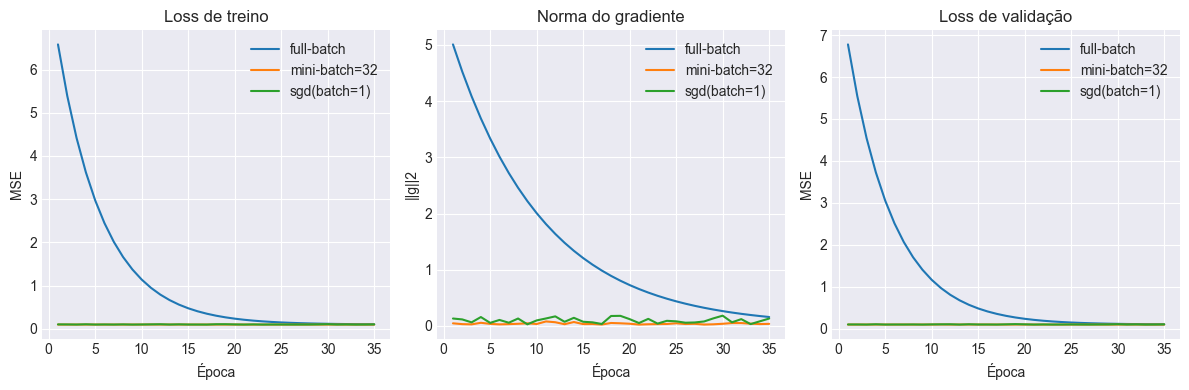

In [37]:

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(hist_full["epoch"], hist_full["train_loss"], label="full-batch")
plt.plot(hist_mb32["epoch"], hist_mb32["train_loss"], label="mini-batch=32")
plt.plot(hist_sgd["epoch"], hist_sgd["train_loss"], label="sgd(batch=1)")
plt.title("Loss de treino")
plt.xlabel("Época"); plt.ylabel("MSE"); plt.legend()

plt.subplot(1,3,2)
plt.plot(hist_full["epoch"], hist_full["grad_norm"], label="full-batch")
plt.plot(hist_mb32["epoch"], hist_mb32["grad_norm"], label="mini-batch=32")
plt.plot(hist_sgd["epoch"], hist_sgd["grad_norm"], label="sgd(batch=1)")
plt.title("Norma do gradiente")
plt.xlabel("Época"); plt.ylabel("||g||2"); plt.legend()

plt.subplot(1,3,3)
plt.plot(hist_full["epoch"], hist_full["valid_loss"], label="full-batch")
plt.plot(hist_mb32["epoch"], hist_mb32["valid_loss"], label="mini-batch=32")
plt.plot(hist_sgd["epoch"], hist_sgd["valid_loss"], label="sgd(batch=1)")
plt.title("Loss de validação")
plt.xlabel("Época"); plt.ylabel("MSE"); plt.legend()

plt.tight_layout()
plt.show()


**Leitura esperada:**
- Full-batch tende a reduzir a perda de forma mais suave por época.
- Mini-batch (ex.: 32) costuma equilibrar custo computacional e estabilidade.
- SGD (batch=1) introduz mais ruído no gradiente; pode precisar de LR menor.

> Em redes profundas reais, mini-batch é padrão por eficiência em GPU e bom compromisso de generalização.


### 1.2 Ruído do gradiente vs tamanho de batch

Vamos medir a variância do estimador de gradiente em diferentes batch sizes no mesmo ponto de parâmetros.


In [38]:

def sample_gradients(X_train, y_train, w, b, batch_size=32, n_samples=250, seed=123):
    rng = np.random.default_rng(seed)
    n = len(X_train)
    grads = []

    for _ in range(n_samples):
        idx = rng.choice(n, size=batch_size, replace=False)
        _, gw, gb = mse_and_grads(X_train[idx], y_train[idx], w, b)
        g = np.concatenate([gw, np.array([gb])], axis=0)
        grads.append(g)

    grads = np.stack(grads, axis=0)
    return grads

# ponto qualquer fora do ótimo
w_probe = np.array([0.5, -0.5], dtype=np.float64)
b_probe = 0.0

batch_sizes = [1, 8, 32, 128, len(X_tr)]
var_per_bs = []

for bs in batch_sizes:
    G = sample_gradients(X_tr, y_tr, w_probe, b_probe, batch_size=bs, n_samples=200, seed=42)
    # variância média por componente
    var_per_bs.append(G.var(axis=0).mean())

pd.DataFrame({"batch_size": batch_sizes, "mean_grad_variance": var_per_bs})


,batch_size,mean_grad_variance
0,1,2.191381e+01
1,8,3.014282e+00
2,32,6.917566e-01
3,128,1.787410e-01
4,2250,3.230878e-29


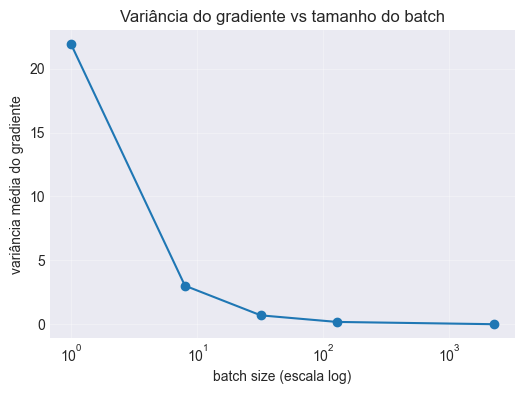

In [39]:

plt.figure(figsize=(6,4))
plt.plot(batch_sizes, var_per_bs, marker="o")
plt.xscale("log")
plt.title("Variância do gradiente vs tamanho do batch")
plt.xlabel("batch size (escala log)")
plt.ylabel("variância média do gradiente")
plt.grid(alpha=0.3)
plt.show()


Batches maiores reduzem ruído do gradiente, mas aumentam custo por passo e podem reduzir “exploração” da paisagem de perda.


---
## 2) Superfície de perda e geometria local

Para visualizar a geometria, usamos uma função quadrática anisotrópica:

\[
$f(w_1, w_2)=\frac{1}{2}(a w_1^2 + b w_2^2), \quad a \gg b$
\]

- Quando \(a $\gg$ b\), temos um “vale estreito” (ravine): uma direção tem curvatura muito maior que outra.
- Isso explica o comportamento de zig-zag do GD em superfícies mal condicionadas.


In [40]:

# Definição da função quadrática e seu gradiente/hessiana
a, bcoef = 30.0, 1.0

def f_quad(w):
    w1, w2 = w
    return 0.5*(a*w1**2 + bcoef*w2**2)

def grad_quad(w):
    w1, w2 = w
    return np.array([a*w1, bcoef*w2], dtype=np.float64)

H = np.array([[a, 0.0],[0.0, bcoef]], dtype=np.float64)
eigvals = np.linalg.eigvalsh(H)
cond_number = eigvals.max()/eigvals.min()

print("Hessian =\n", H)
print("Autovalores:", eigvals)
print("Condition number:", round(float(cond_number), 2))


Hessian =
 [[30.  0.]
 [ 0.  1.]]
Autovalores: [ 1. 30.]
Condition number: 30.0


### 2.1 Visualizando a superfície (contornos)


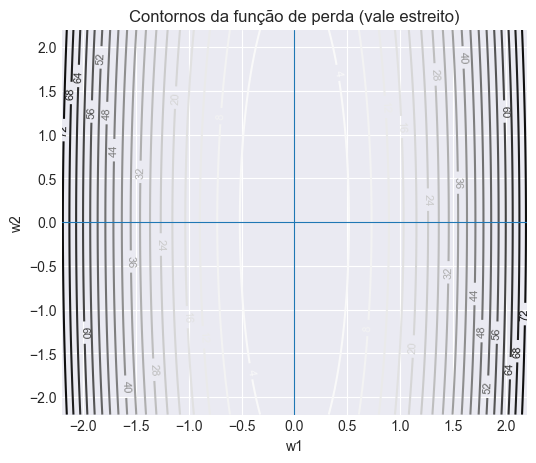

In [41]:

w1 = np.linspace(-2.2, 2.2, 250)
w2 = np.linspace(-2.2, 2.2, 250)
W1, W2 = np.meshgrid(w1, w2)
Z = 0.5*(a*W1**2 + bcoef*W2**2)

plt.figure(figsize=(6,5))
cs = plt.contour(W1, W2, Z, levels=20)
plt.clabel(cs, inline=True, fontsize=8)
plt.title("Contornos da função de perda (vale estreito)")
plt.xlabel("w1"); plt.ylabel("w2")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.show()


### 2.2 Trajetória do gradiente descendente em diferentes learning rates


In [42]:

def gd_path(w0, lr=0.05, steps=40):
    w = np.array(w0, dtype=np.float64)
    path = [w.copy()]
    for _ in range(steps):
        w = w - lr*grad_quad(w)
        path.append(w.copy())
    return np.array(path)

path_lr_small = gd_path([1.8, 1.8], lr=0.02, steps=40)
path_lr_good  = gd_path([1.8, 1.8], lr=0.05, steps=40)
path_lr_high  = gd_path([1.8, 1.8], lr=0.09, steps=40)  # próximo da fronteira de estabilidade


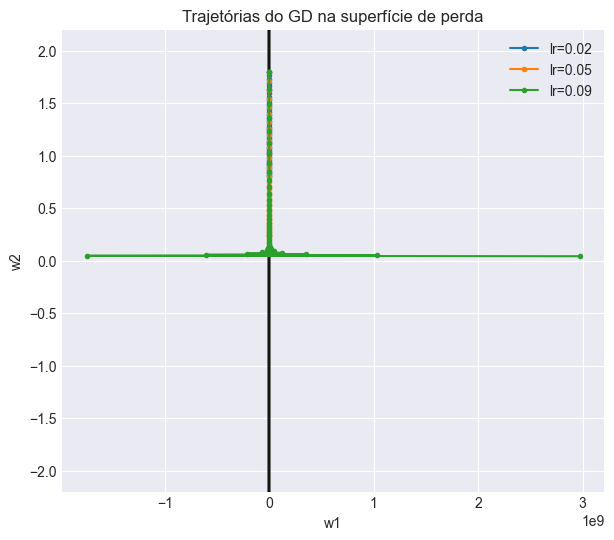

In [43]:

plt.figure(figsize=(7,6))
plt.contour(W1, W2, Z, levels=25)

for p, name in [
    (path_lr_small, "lr=0.02"),
    (path_lr_good,  "lr=0.05"),
    (path_lr_high,  "lr=0.09"),
]:
    plt.plot(p[:,0], p[:,1], marker="o", markersize=3, linewidth=1.5, label=name)

plt.title("Trajetórias do GD na superfície de perda")
plt.xlabel("w1"); plt.ylabel("w2")
plt.legend()
plt.show()


**Interpretação:**
- LR muito baixo: progresso lento.
- LR adequado: convergência eficiente.
- LR alto (próximo do limite): oscilações / risco de divergir.

A geometria local (curvatura) impõe limites para escolhas de LR.


---
## 3) Taxa de aprendizado como hiperparâmetro crítico (experimento em rede neural)

Agora vamos para um cenário típico de Deep Learning: MLP em classificação `make_moons`.


In [44]:

def make_torch_loaders(
    X: np.ndarray, y: np.ndarray,
    batch_size: int = 64,
    valid_size: float = 0.3,
    stratify: bool = True,
    seed: int = 42
):
    y_strat = y if stratify else None
    X_tr, X_va, y_tr, y_va = train_test_split(
        X, y, test_size=valid_size, random_state=seed, stratify=y_strat
    )

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32).view(-1, 1)
    X_va_t = torch.tensor(X_va, dtype=torch.float32)
    y_va_t = torch.tensor(y_va, dtype=torch.float32).view(-1, 1)

    tr_ds = TensorDataset(X_tr_t, y_tr_t)
    va_ds = TensorDataset(X_va_t, y_va_t)

    tr_dl = DataLoader(tr_ds, batch_size=batch_size, shuffle=True)
    va_dl = DataLoader(va_ds, batch_size=batch_size, shuffle=False)
    return tr_dl, va_dl, (X_tr, X_va, y_tr, y_va)

class MLPBinary(nn.Module):
    def __init__(self, hidden_sizes=[64, 64], activation="relu"):
        super().__init__()
        layers = []
        in_dim = 2
        act_cls = nn.ReLU if activation == "relu" else nn.Tanh

        for h in hidden_sizes:
            layers += [nn.Linear(in_dim, h), act_cls()]
            in_dim = h
        layers += [nn.Linear(in_dim, 1)]  # logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

@dataclass
class TrainConfig:
    epochs: int = 80
    lr: float = 1e-2
    batch_size: int = 64
    momentum: float = 0.0
    weight_decay: float = 0.0
    verbose_every: int = 20

def train_binary_model(model, train_dl, valid_dl, cfg: TrainConfig, device=device):
    criterion = nn.BCEWithLogitsLoss()
    opt = torch.optim.SGD(
        model.parameters(),
        lr=cfg.lr,
        momentum=cfg.momentum,
        weight_decay=cfg.weight_decay
    )

    model.to(device)
    hist = []

    for ep in range(1, cfg.epochs + 1):
        model.train()
        train_losses, train_probs, train_true = [], [], []

        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            opt.step()

            train_losses.append(loss.item())
            probs = torch.sigmoid(logits).detach().cpu().numpy().ravel()
            train_probs.extend(probs.tolist())
            train_true.extend(yb.detach().cpu().numpy().ravel().tolist())

        model.eval()
        valid_losses, valid_probs, valid_true = [], [], []
        with torch.no_grad():
            for xb, yb in valid_dl:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                valid_losses.append(loss.item())
                probs = torch.sigmoid(logits).cpu().numpy().ravel()
                valid_probs.extend(probs.tolist())
                valid_true.extend(yb.cpu().numpy().ravel().tolist())

        tr_pred = (np.array(train_probs) >= 0.5).astype(int)
        va_pred = (np.array(valid_probs) >= 0.5).astype(int)

        tr_acc = accuracy_score(np.array(train_true).astype(int), tr_pred)
        va_acc = accuracy_score(np.array(valid_true).astype(int), va_pred)

        hist.append({
            "epoch": ep,
            "train_loss": float(np.mean(train_losses)),
            "valid_loss": float(np.mean(valid_losses)),
            "train_acc": tr_acc,
            "valid_acc": va_acc
        })

        if ep % cfg.verbose_every == 0:
            print(f"Epoch {ep:03d} | train_loss={hist[-1]['train_loss']:.4f} | valid_loss={hist[-1]['valid_loss']:.4f} | valid_acc={hist[-1]['valid_acc']:.3f}")

    return pd.DataFrame(hist)


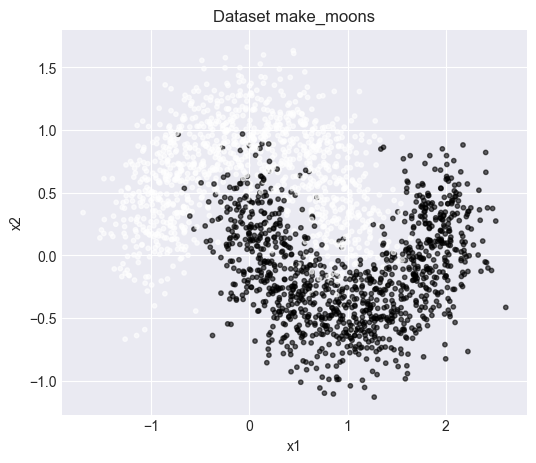

In [45]:

# dataset de classificação não linear
set_seed(42)
X, y = make_moons(n_samples=2200, noise=0.25, random_state=42)
train_dl, valid_dl, split = make_torch_loaders(X, y, batch_size=64, valid_size=0.35, seed=42)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, s=10, alpha=0.6)
plt.title("Dataset make_moons")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()


### 3.1 Comparando três learning rates

Vamos testar:
- **muito baixo** (aprende devagar),
- **adequado** (converge bem),
- **alto** (pode oscilar/divergir).


In [46]:

lrs = [1e-4, 1e-2, 2e-1]
histories_lr = {}

for lr in lrs:
    set_seed(42)
    model = MLPBinary(hidden_sizes=[64,64], activation="relu")
    cfg = TrainConfig(epochs=80, lr=lr, momentum=0.0, verbose_every=1000)  # sem prints intermediários
    h = train_binary_model(model, train_dl, valid_dl, cfg, device=device)
    histories_lr[lr] = h

summary = []
for lr, h in histories_lr.items():
    summary.append({
        "lr": lr,
        "best_valid_acc": h["valid_acc"].max(),
        "final_valid_acc": h["valid_acc"].iloc[-1],
        "final_valid_loss": h["valid_loss"].iloc[-1]
    })

pd.DataFrame(summary).sort_values("lr")


,lr,best_valid_acc,final_valid_acc,final_valid_loss
0,0.0001,0.725974,0.725974,0.664685
1,0.0100,0.864935,0.864935,0.276660
2,0.2000,0.945455,0.936364,0.147402


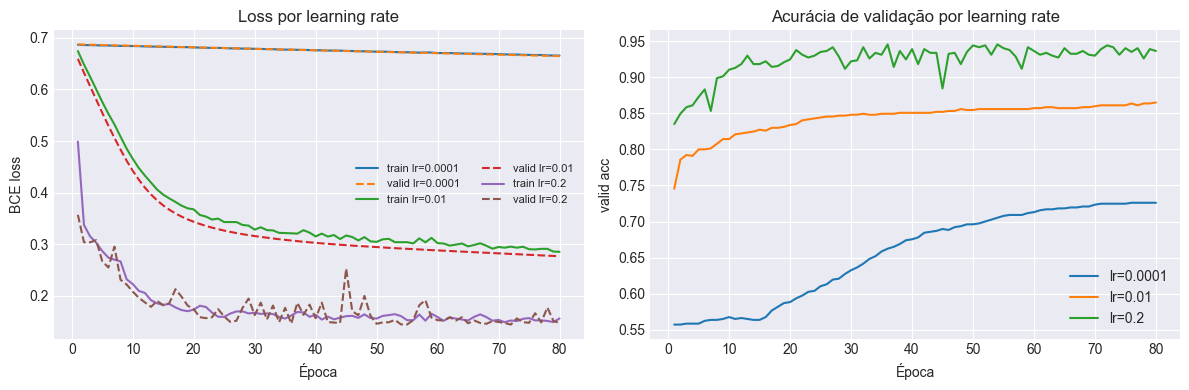

In [47]:

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
for lr, h in histories_lr.items():
    plt.plot(h["epoch"], h["train_loss"], label=f"train lr={lr}")
    plt.plot(h["epoch"], h["valid_loss"], linestyle="--", label=f"valid lr={lr}")
plt.title("Loss por learning rate")
plt.xlabel("Época"); plt.ylabel("BCE loss")
plt.legend(ncol=2, fontsize=8)

plt.subplot(1,2,2)
for lr, h in histories_lr.items():
    plt.plot(h["epoch"], h["valid_acc"], label=f"lr={lr}")
plt.title("Acurácia de validação por learning rate")
plt.xlabel("Época"); plt.ylabel("valid acc")
plt.legend()

plt.tight_layout()
plt.show()


**Regra prática inicial para tuning de LR:**
1. Comece com um valor razoável para o otimizador (ex.: SGD 1e-2 ou AdamW 1e-3).
2. Observe os primeiros epochs:
   - loss sobe/oscila demais → LR possivelmente alto;
   - loss quase não muda → LR possivelmente baixo.
3. Ajuste em escala logarítmica (×10 ou ÷10).


---
## 4) Momentum e intuição física da otimização

### Intuição

Sem momentum, cada passo usa só o gradiente atual.  
Com momentum, mantemos uma **velocidade acumulada**:

\[
$v_t = \beta v_{t-1} + g_t, \qquad
\theta_{t+1} = \theta_t - \eta v_t$
\]

- \($\beta$\) (ex.: 0.9): “inércia/memória” do movimento.
- Em vales estreitos, momentum reduz zig-zag e acelera avanço na direção útil.


### 4.1 Demonstração em função quadrática (trajetórias)


In [48]:

def momentum_path(w0, lr=0.05, beta=0.9, steps=40):
    w = np.array(w0, dtype=np.float64)
    v = np.zeros_like(w)
    path = [w.copy()]
    for _ in range(steps):
        g = grad_quad(w)
        v = beta * v + g
        w = w - lr * v
        path.append(w.copy())
    return np.array(path)

path_plain = momentum_path([1.8, 1.8], lr=0.05, beta=0.0, steps=40)  # sem momentum
path_m09   = momentum_path([1.8, 1.8], lr=0.05, beta=0.9, steps=40)  # com momentum


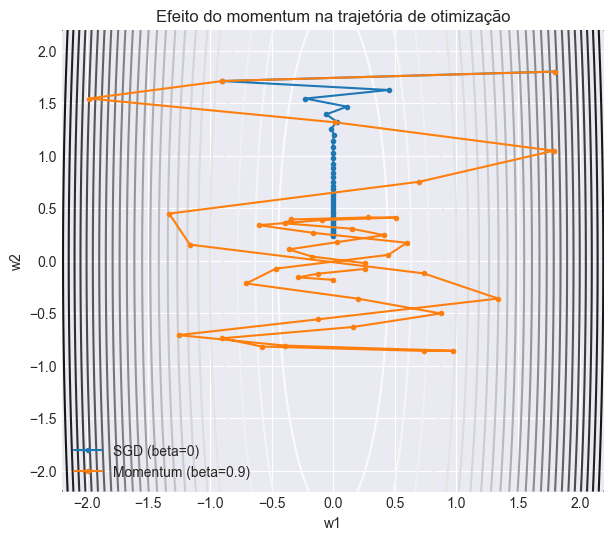

In [49]:

plt.figure(figsize=(7,6))
plt.contour(W1, W2, Z, levels=25)
plt.plot(path_plain[:,0], path_plain[:,1], marker="o", markersize=3, linewidth=1.5, label="SGD (beta=0)")
plt.plot(path_m09[:,0], path_m09[:,1], marker="o", markersize=3, linewidth=1.5, label="Momentum (beta=0.9)")
plt.title("Efeito do momentum na trajetória de otimização")
plt.xlabel("w1"); plt.ylabel("w2")
plt.legend()
plt.show()


### 4.2 Momentum em rede neural (SGD vs SGD+momentum)


In [50]:

set_seed(42)
model_plain = MLPBinary(hidden_sizes=[64,64], activation="relu")
cfg_plain = TrainConfig(epochs=80, lr=0.02, momentum=0.0, verbose_every=1000)
hist_plain = train_binary_model(model_plain, train_dl, valid_dl, cfg_plain, device=device)

set_seed(42)
model_mom = MLPBinary(hidden_sizes=[64,64], activation="relu")
cfg_mom = TrainConfig(epochs=80, lr=0.02, momentum=0.9, verbose_every=1000)
hist_mom = train_binary_model(model_mom, train_dl, valid_dl, cfg_mom, device=device)

print("Final valid acc (sem momentum):", round(hist_plain['valid_acc'].iloc[-1], 4))
print("Final valid acc (com momentum):", round(hist_mom['valid_acc'].iloc[-1], 4))


Final valid acc (sem momentum): 0.8974
Final valid acc (com momentum): 0.939


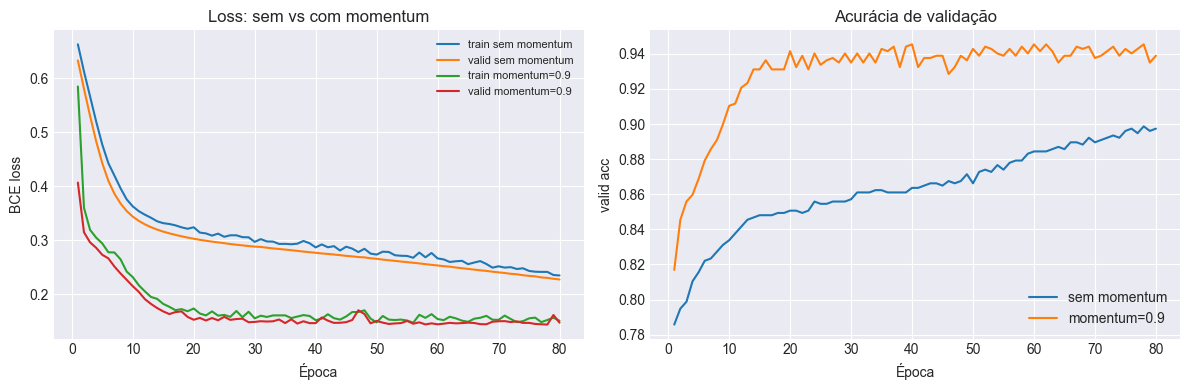

In [51]:

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(hist_plain["epoch"], hist_plain["train_loss"], label="train sem momentum")
plt.plot(hist_plain["epoch"], hist_plain["valid_loss"], label="valid sem momentum")
plt.plot(hist_mom["epoch"], hist_mom["train_loss"], label="train momentum=0.9")
plt.plot(hist_mom["epoch"], hist_mom["valid_loss"], label="valid momentum=0.9")
plt.title("Loss: sem vs com momentum")
plt.xlabel("Época"); plt.ylabel("BCE loss")
plt.legend(fontsize=8)

plt.subplot(1,2,2)
plt.plot(hist_plain["epoch"], hist_plain["valid_acc"], label="sem momentum")
plt.plot(hist_mom["epoch"], hist_mom["valid_acc"], label="momentum=0.9")
plt.title("Acurácia de validação")
plt.xlabel("Época"); plt.ylabel("valid acc")
plt.legend()

plt.tight_layout()
plt.show()


**Resumo da intuição física:**
- O gradiente é como “força instantânea”.
- O momentum adiciona “massa/inércia” ao sistema.
- Resultado: menos zig-zag em direções íngremes e mais velocidade na direção de descida consistente.


In [52]:
# Experimento Interativo: A Ravina
print("MISSÃO: Tente chegar na estrela dourada (0,0) em menos de 50 passos.")
print("1. Veja como o SGD Puro oscila violentamente se o LR for alto.")
print("2. Mude para Momentum e veja a mágica da 'Física' estabilizando a descida.")

interact(plot_optimization_path,
         func_name=widgets.fixed('Ravina (Ill-Conditioned)'),
         optimizer_name=ToggleButtons(options=['SGD Puro', 'SGD + Momentum']),
         lr=FloatSlider(min=0.01, max=0.5, step=0.01, value=0.05, description='Learning Rate'),
         momentum=FloatSlider(min=0.0, max=0.99, step=0.01, value=0.9, description='Momentum (Beta)'),
         steps=widgets.fixed(50));

MISSÃO: Tente chegar na estrela dourada (0,0) em menos de 50 passos.
1. Veja como o SGD Puro oscila violentamente se o LR for alto.
2. Mude para Momentum e veja a mágica da 'Física' estabilizando a descida.


interactive(children=(ToggleButtons(description='optimizer_name', options=('SGD Puro', 'SGD + Momentum'), valu…

In [53]:
# Experimento 3: A Caminhada do Bêbado (Stochastic Walk)

def visualize_random_walk(batch_noise=0.0):
    # Configuração do "Vale" (Função Loss: x^2 + y^2)
    # O objetivo é chegar em (0,0) partindo de (-4, -4)

    steps = 50
    lr = 0.1

    # Caminho IDEAL (Sem ruído nenhum - Full Batch)
    path_ideal = [np.array([-4.0, -4.0])]
    curr = path_ideal[0]
    for _ in range(steps):
        grad = 2 * curr # Gradiente de x^2 é 2x
        curr = curr - lr * grad
        path_ideal.append(curr)
    path_ideal = np.array(path_ideal)

    # Caminho RUIDOSO (Simulando Mini-batch com ruído)
    # Quanto menor o batch, maior esse "batch_noise"
    np.random.seed(42)
    path_noisy = [np.array([-4.0, -4.0])]
    curr = path_noisy[0]

    for _ in range(steps):
        # Gradiente real + "Erro" do mini-batch (Ruído aleatório)
        true_grad = 2 * curr
        noise_x = np.random.normal(0, batch_noise)
        noise_y = np.random.normal(0, batch_noise)
        noisy_grad = true_grad + np.array([noise_x, noise_y])

        curr = curr - lr * noisy_grad
        path_noisy.append(curr)
    path_noisy = np.array(path_noisy)

    # --- Plotagem ---
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # Fundo (Contornos da montanha)
    x = np.linspace(-5, 5, 100)
    y = np.linspace(-5, 5, 100)
    X, Y = np.meshgrid(x, y)
    Z = X**2 + Y**2

    # Gráfico 1: O Ideal (Referência)
    ax[0].contour(X, Y, Z, levels=15, cmap='Greys', alpha=0.3)
    ax[0].plot(path_ideal[:,0], path_ideal[:,1], 'o-', color='green', label='Caminho Perfeito (Batch Gigante)')
    ax[0].plot(0, 0, 'r*', markersize=15, label='Alvo (Mínimo)')
    ax[0].set_title("Otimização Estável (Full Batch)")
    ax[0].set_xlim(-5, 5); ax[0].set_ylim(-5, 5)
    ax[0].legend()

    # Gráfico 2: O Real (Com Ruído)
    ax[1].contour(X, Y, Z, levels=15, cmap='Greys', alpha=0.3)
    ax[1].plot(path_noisy[:,0], path_noisy[:,1], 'o-', color='blue', alpha=0.7, label=f'Seu Caminho (Ruído={batch_noise})')
    # Plota o ideal por baixo para comparação
    ax[1].plot(path_ideal[:,0], path_ideal[:,1], '--', color='green', alpha=0.3)
    ax[1].plot(0, 0, 'r*', markersize=15)
    ax[1].set_title(f"Otimização Estocástica (Mini-Batch)")
    ax[1].set_xlim(-5, 5); ax[1].set_ylim(-5, 5)
    ax[1].legend()

    plt.suptitle("Impacto do Tamanho do Batch na Trajetória", fontsize=16)
    plt.show()

print("MOVA O SLIDER PARA A DIREITA:")
print("Esquerda (0): Batch Gigante (Linha Reta e Perfeita)")
print("Direita (10): Batch Minúsculo (O modelo 'treme' e se perde no caminho)")

interact(visualize_random_walk,
         batch_noise=FloatSlider(min=0.0, max=10.0, step=0.5, value=2.0, description='Instabilidade'));

MOVA O SLIDER PARA A DIREITA:
Esquerda (0): Batch Gigante (Linha Reta e Perfeita)
Direita (10): Batch Minúsculo (O modelo 'treme' e se perde no caminho)


interactive(children=(FloatSlider(value=2.0, description='Instabilidade', max=10.0, step=0.5), Output()), _dom…

In [54]:
# Experimento 3: Visualizando a Estabilidade do Gradiente

def visualize_gradient_noise(batch_size=1):
    # 1. Dados Sintéticos (Regressão Linear: y = 2x + 1 + ruído)
    torch.manual_seed(42)
    X = torch.linspace(-1, 1, 100).view(-1, 1)
    y = 2 * X + 1 + torch.randn(X.size()) * 0.5

    # Modelo inicial fixo (longe do ideal para gerar gradientes fortes)
    model = torch.nn.Linear(1, 1)
    with torch.no_grad():
        model.weight.fill_(5.0) # Errado (deveria ser 2)
        model.bias.fill_(-2.0)  # Errado (deveria ser 1)

    # 2. Calcular gradientes para VÁRIOS mini-batches
    grad_ws = []
    grad_bs = []

    # Passar pelo dataset em batches e coletar os gradientes SEM atualizar
    dataset = torch.utils.data.TensorDataset(X, y)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    loss_fn = torch.nn.MSELoss()

    for x_batch, y_batch in loader:
        model.zero_grad()
        loss = loss_fn(model(x_batch), y_batch)
        loss.backward()
        grad_ws.append(model.weight.grad.item())
        grad_bs.append(model.bias.grad.item())
        if len(grad_ws) > 50: break # Limitar pontos para plot não poluir

    # 3. Calcular o "Gradiente Real" (Full Batch)
    model.zero_grad()
    loss_full = loss_fn(model(X), y)
    loss_full.backward()
    true_grad_w = model.weight.grad.item()
    true_grad_b = model.bias.grad.item()

    # 4. Plot
    plt.figure(figsize=(8, 8))
    plt.scatter(grad_ws, grad_bs, alpha=0.6, label=f'Mini-batches (N={batch_size})', c='blue')
    plt.scatter(true_grad_w, true_grad_b, s=200, c='red', marker='X', label='Gradiente Real (Todo Dataset)')

    plt.title(f"Dispersão dos Gradientes (Batch Size = {batch_size})")
    plt.xlabel("Gradiente do Peso (dW)")
    plt.ylabel("Gradiente do Bias (db)")
    plt.axhline(0, color='gray', ls='--')
    plt.axvline(0, color='gray', ls='--')
    plt.legend()
    plt.grid(True)

    # Círculo de variância
    radius = np.std(grad_ws) + np.std(grad_bs)
    circle = plt.Circle((true_grad_w, true_grad_b), radius, color='red', fill=False, linestyle='--', alpha=0.5)
    plt.gca().add_patch(circle)

    plt.show()

print("Veja como Batch Size pequeno gera gradientes 'bêbados' (alta variância).")
print("Batch Size grande aproxima o gradiente real (ponto vermelho).")
interact(visualize_gradient_noise,
         batch_size=IntSlider(min=1, max=100, step=5, value=1, description='Batch Size'));

Veja como Batch Size pequeno gera gradientes 'bêbados' (alta variância).
Batch Size grande aproxima o gradiente real (ponto vermelho).


interactive(children=(IntSlider(value=1, description='Batch Size', min=1, step=5), Output()), _dom_classes=('w…

In [55]:
# Experimento: A Geometria da Generalização (Flat vs Sharp)
# Por que o SGD funciona?

def visualize_flat_vs_sharp(perturbation=0.0):
    x = np.linspace(-2, 2, 400)

    # 1. Mínimo Agudo (Sharp): Um buraco profundo e estreito
    # Simula um modelo overfitado ou treinado com batch gigante
    sharp_loss = 10 * x**2  # Curvatura alta
    # Vamos "cortar" visualmente para parecer um buraco
    sharp_loss = np.clip(sharp_loss, 0, 4)

    # 2. Mínimo Achatado (Flat): Um vale suave
    # Simula um modelo robusto (SGD com ruído)
    flat_loss = 1 * x**2    # Curvatura baixa

    plt.figure(figsize=(10, 6))

    # Plotar as curvas de Loss
    plt.plot(x, sharp_loss, label='Modelo A (Mínimo Agudo)', color='red', linewidth=2)
    plt.plot(x, flat_loss, label='Modelo B (Mínimo Achatado)', color='blue', linewidth=2)

    # Simular a Solução Encontrada (Ambos chegaram no zero)
    # Mas agora aplicamos uma "Perturbação" (Mudança nos dados ou precisão numérica)
    current_pos = 0.0 + perturbation

    # Calcular o erro resultante da perturbação
    loss_sharp = 10 * (current_pos**2)
    loss_flat = 1 * (current_pos**2)
    loss_sharp = min(loss_sharp, 4) # Clip visual

    # Visualizar o impacto
    plt.plot(current_pos, loss_sharp, 'ro', markersize=10)
    plt.plot(current_pos, loss_flat, 'bo', markersize=10)

    # Barras de erro visual
    plt.vlines(current_pos, 0, loss_sharp, color='red', linestyle='--', alpha=0.5)
    plt.vlines(current_pos, 0, loss_flat, color='blue', linestyle='--', alpha=0.5)

    plt.title(f"Sensibilidade a Mudanças (Perturbação nos Pesos: {perturbation:.2f})")
    plt.ylabel("Loss (Erro)")
    plt.xlabel("Espaço de Parâmetros (Pesos)")
    plt.ylim(-0.5, 4.5)

    # Anotação de Impacto
    plt.text(-1.5, 3.5, f"Erro Modelo A: {loss_sharp:.2f}\nErro Modelo B: {loss_flat:.2f}",
             bbox=dict(facecolor='white', alpha=0.8), fontsize=12)

    plt.legend()
    plt.show()

print("CONCEITO SOTA: Ambos os modelos têm Loss=0 no treino (x=0).")
print("Mas se mudarmos um pouco os dados (mover slider), qual erro explode?")
print("Isso explica por que Batch Size Pequeno (que acha vales largos) generaliza melhor.")

interact(visualize_flat_vs_sharp,
         perturbation=FloatSlider(min=-0.5, max=0.5, step=0.05, value=0.0, description='Shift (Ruído)'));

CONCEITO SOTA: Ambos os modelos têm Loss=0 no treino (x=0).
Mas se mudarmos um pouco os dados (mover slider), qual erro explode?
Isso explica por que Batch Size Pequeno (que acha vales largos) generaliza melhor.


interactive(children=(FloatSlider(value=0.0, description='Shift (Ruído)', max=0.5, min=-0.5, step=0.05), Outpu…

O Conceito: **"Não basta descer, tem que ser largo"**
Pesquisas modernas (como Hochreiter & Schmidhuber e, mais recentemente, Keskar et al. sobre "Large Batch Training") mostram que:

1.   Mínimo Agudo (Sharp): O modelo atinge Loss=0, mas está num "buraco de agulha". Se os dados de teste forem levemente diferentes (deslocamento de domínio), a loss explode.

2.   Mínimo Achatado (Flat): O modelo está num "vale largo". Mesmo que os pesos variem um pouco ou os dados mudem, a performance se mantém.


**Por que isso importa?**
Isso explica fisicamente por que Batch Size pequeno geralmente generaliza melhor que Batch Size gigante (o ruído do SGD empurra o modelo para vales mais largos, enquanto o Full Batch cai no primeiro buraco fundo que encontra).

---
## 5) Checklist rápido para prática em projetos reais

1. **Comece pelo LR** (é o hiperparâmetro com maior impacto inicial).  
2. Use **mini-batch** compatível com memória/throughput de hardware.  
3. Se o treino oscilar com SGD, teste:
   - LR menor,
   - momentum (0.8–0.95),
   - clipping (em casos extremos).  
4. Analise curvas de treino/validação por época (não apenas métrica final).  
5. Registre experimentos (seed, config, dataset split) para reprodutibilidade.


## 6) Exercícios sugeridos

1. Repetir o experimento de LR com valores intermediários (3e-3, 5e-3, 3e-2).  
2. Medir tempo de treino e desempenho com batch sizes diferentes (16, 64, 256).  
3. Comparar SGD+momentum com Adam no mesmo problema.  
4. No exemplo quadrático, variar \(a/b\) e observar impacto do condicionamento na trajetória.  
5. Criar um “guia de decisão” para escolher LR e momentum em um projeto novo.


---
## 7) Soluções dos Exercícios

### Exercício 1: Experimentar valores intermediários de Learning Rate

In [56]:
# Exercício 1: Testar valores intermediários de Learning Rate

import time
from sklearn.datasets import make_classification

# Preparar dados
set_seed(42)
X_lr, y_lr = make_classification(
    n_samples=2000, n_features=20, n_informative=15,
    n_redundant=3, n_classes=2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_lr, y_lr, test_size=0.3, random_state=42, stratify=y_lr
)

# Converter para tensores
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Modelo simples
class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.net(x)

# Função de treino
def train_with_lr(lr, epochs=100, verbose=False):
    set_seed(42)
    model = SimpleMLP(X_train.shape[1]).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    
    history = {
        'epoch': [], 'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }
    
    start_time = time.time()
    
    for epoch in range(epochs):
        # Treino
        model.train()
        train_losses = []
        train_preds, train_labels = [], []
        
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(yb.cpu().numpy())
        
        # Validação
        model.eval()
        val_losses = []
        val_preds, val_labels = [], []
        
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_losses.append(loss.item())
                
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(yb.cpu().numpy())
        
        train_acc = accuracy_score(train_labels, train_preds)
        val_acc = accuracy_score(val_labels, val_preds)
        
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(np.mean(val_losses))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if verbose and (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}: train_loss={history['train_loss'][-1]:.4f}, "
                  f"val_acc={val_acc:.4f}")
    
    training_time = time.time() - start_time
    
    return pd.DataFrame(history), training_time, model

# Testar diferentes Learning Rates
learning_rates = [1e-4, 3e-4, 1e-3, 3e-3, 5e-3, 1e-2, 3e-2, 5e-2, 1e-1]
results = {}

print("🔍 Testando diferentes Learning Rates...")
print("=" * 70)

for lr in learning_rates:
    print(f"\nLR = {lr:.0e}...", end=" ")
    hist, train_time, model = train_with_lr(lr, epochs=100, verbose=False)
    results[lr] = {
        'history': hist,
        'time': train_time,
        'final_val_acc': hist['val_acc'].iloc[-1],
        'best_val_acc': hist['val_acc'].max(),
        'final_train_loss': hist['train_loss'].iloc[-1],
        'converged': hist['train_loss'].iloc[-1] < 0.1
    }
    print(f"✓ Val Acc: {results[lr]['final_val_acc']:.4f} | "
          f"Time: {train_time:.2f}s")

print("\n" + "=" * 70)

🔍 Testando diferentes Learning Rates...

LR = 1e-04... ✓ Val Acc: 0.6133 | Time: 1.36s

LR = 3e-04... ✓ Val Acc: 0.7267 | Time: 1.23s

LR = 1e-03... ✓ Val Acc: 0.8000 | Time: 1.23s

LR = 3e-03... ✓ Val Acc: 0.8767 | Time: 1.23s

LR = 5e-03... ✓ Val Acc: 0.8967 | Time: 1.43s

LR = 1e-02... ✓ Val Acc: 0.9367 | Time: 1.18s

LR = 3e-02... ✓ Val Acc: 0.9600 | Time: 1.24s

LR = 5e-02... ✓ Val Acc: 0.9600 | Time: 1.23s

LR = 1e-01... ✓ Val Acc: 0.9617 | Time: 1.31s



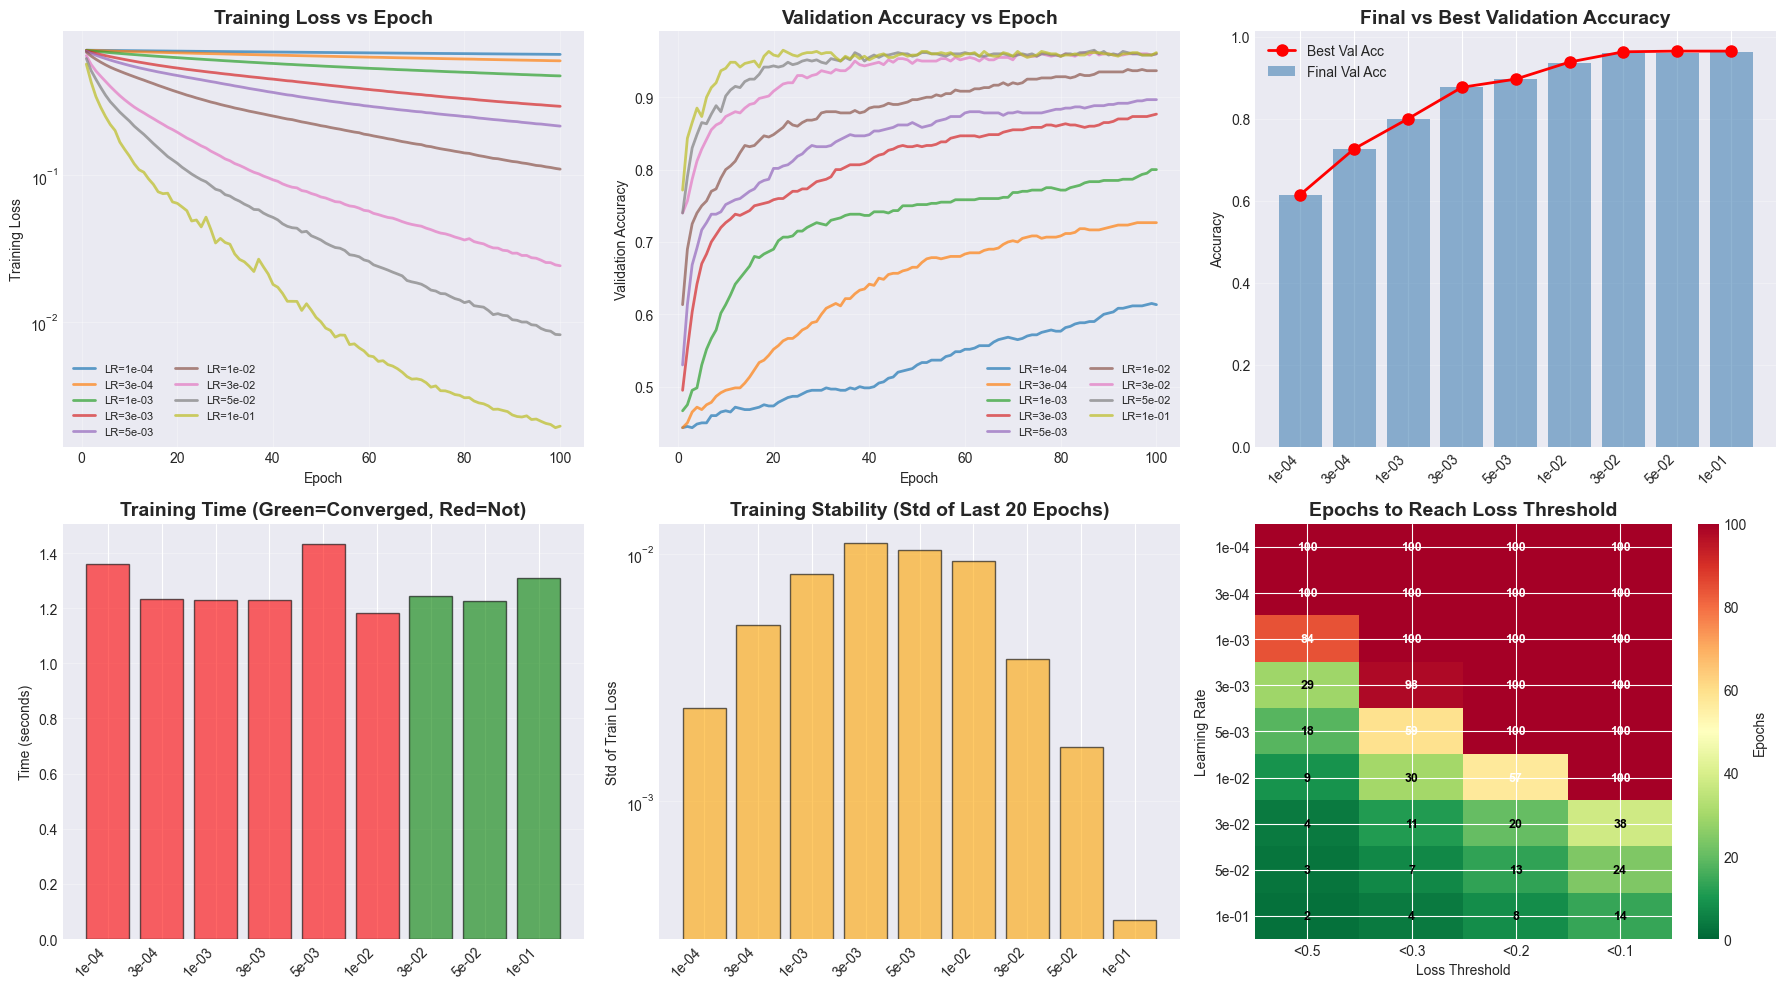


📊 RESUMO COMPARATIVO DOS LEARNING RATES
LR          Final Val Acc   Best Val Acc    Converged    Time(s)
------------------------------------------------------------------------------------------
1e-04              0.6133         0.6150            ✗       1.36
3e-04              0.7267         0.7267            ✗       1.23
1e-03              0.8000         0.8000            ✗       1.23
3e-03              0.8767         0.8767            ✗       1.23
5e-03              0.8967         0.8967            ✗       1.43
1e-02              0.9367         0.9383            ✗       1.18
3e-02              0.9600         0.9633            ✓       1.24
5e-02              0.9600         0.9650            ✓       1.23
1e-01              0.9617         0.9650            ✓       1.31

🏆 MELHOR LEARNING RATE: 5e-02
   • Best Val Accuracy: 0.9650
   • Training Time: 1.23s
   • Convergiu: Sim

💡 INSIGHTS:
------------------------------------------------------------------------------------------
• LR m

In [57]:
# Visualização comparativa dos Learning Rates

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Curvas de Loss
ax = axes[0, 0]
for lr in learning_rates:
    hist = results[lr]['history']
    ax.plot(hist['epoch'], hist['train_loss'], label=f'LR={lr:.0e}', alpha=0.7, linewidth=2)
ax.set_title('Training Loss vs Epoch', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_yscale('log')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)

# 2. Curvas de Validation Accuracy
ax = axes[0, 1]
for lr in learning_rates:
    hist = results[lr]['history']
    ax.plot(hist['epoch'], hist['val_acc'], label=f'LR={lr:.0e}', alpha=0.7, linewidth=2)
ax.set_title('Validation Accuracy vs Epoch', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)

# 3. Performance Final por LR
ax = axes[0, 2]
lrs_str = [f'{lr:.0e}' for lr in learning_rates]
final_accs = [results[lr]['final_val_acc'] for lr in learning_rates]
best_accs = [results[lr]['best_val_acc'] for lr in learning_rates]

x_pos = np.arange(len(learning_rates))
ax.bar(x_pos, final_accs, alpha=0.6, label='Final Val Acc', color='steelblue')
ax.plot(x_pos, best_accs, 'ro-', label='Best Val Acc', markersize=8, linewidth=2)
ax.set_xticks(x_pos)
ax.set_xticklabels(lrs_str, rotation=45, ha='right')
ax.set_title('Final vs Best Validation Accuracy', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(alpha=0.3, axis='y')

# 4. Tempo de Convergência
ax = axes[1, 0]
times = [results[lr]['time'] for lr in learning_rates]
colors = ['green' if results[lr]['converged'] else 'red' for lr in learning_rates]
ax.bar(x_pos, times, color=colors, alpha=0.6, edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(lrs_str, rotation=45, ha='right')
ax.set_title('Training Time (Green=Converged, Red=Not)', fontsize=14, fontweight='bold')
ax.set_ylabel('Time (seconds)')
ax.grid(alpha=0.3, axis='y')

# 5. Estabilidade do Treino (Variância da Loss)
ax = axes[1, 1]
loss_stds = []
for lr in learning_rates:
    hist = results[lr]['history']
    # Variância das últimas 20 épocas
    loss_std = hist['train_loss'].iloc[-20:].std()
    loss_stds.append(loss_std)

ax.bar(x_pos, loss_stds, alpha=0.6, color='orange', edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(lrs_str, rotation=45, ha='right')
ax.set_title('Training Stability (Std of Last 20 Epochs)', fontsize=14, fontweight='bold')
ax.set_ylabel('Std of Train Loss')
ax.set_yscale('log')
ax.grid(alpha=0.3, axis='y')

# 6. Mapa de Calor: Epochs para atingir thresholds
ax = axes[1, 2]
thresholds = [0.5, 0.3, 0.2, 0.1]
heatmap_data = []

for lr in learning_rates:
    hist = results[lr]['history']
    row = []
    for thresh in thresholds:
        epochs_to_reach = hist[hist['train_loss'] < thresh]['epoch'].min()
        if pd.isna(epochs_to_reach):
            epochs_to_reach = 100  # Não atingiu
        row.append(epochs_to_reach)
    heatmap_data.append(row)

im = ax.imshow(heatmap_data, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=100)
ax.set_xticks(range(len(thresholds)))
ax.set_xticklabels([f'<{t}' for t in thresholds])
ax.set_yticks(range(len(learning_rates)))
ax.set_yticklabels(lrs_str)
ax.set_title('Epochs to Reach Loss Threshold', fontsize=14, fontweight='bold')
ax.set_xlabel('Loss Threshold')
ax.set_ylabel('Learning Rate')

# Adicionar valores no heatmap
for i in range(len(learning_rates)):
    for j in range(len(thresholds)):
        val = heatmap_data[i][j]
        text_color = 'white' if val > 50 else 'black'
        text = ax.text(j, i, f'{int(val)}', ha="center", va="center",
                      color=text_color, fontsize=9, fontweight='bold')

plt.colorbar(im, ax=ax, label='Epochs')

plt.tight_layout()
plt.show()

# Tabela resumo
print("\n" + "=" * 90)
print("📊 RESUMO COMPARATIVO DOS LEARNING RATES")
print("=" * 90)
print(f"{'LR':<10} {'Final Val Acc':>14} {'Best Val Acc':>14} {'Converged':>12} {'Time(s)':>10}")
print("-" * 90)

for lr in learning_rates:
    r = results[lr]
    converged_str = "✓" if r['converged'] else "✗"
    print(f"{lr:<10.0e} {r['final_val_acc']:>14.4f} {r['best_val_acc']:>14.4f} "
          f"{converged_str:>12} {r['time']:>10.2f}")

print("=" * 90)

# Encontrar o melhor LR
best_lr = max(learning_rates, key=lambda lr: results[lr]['best_val_acc'])
print(f"\n🏆 MELHOR LEARNING RATE: {best_lr:.0e}")
print(f"   • Best Val Accuracy: {results[best_lr]['best_val_acc']:.4f}")
print(f"   • Training Time: {results[best_lr]['time']:.2f}s")
print(f"   • Convergiu: {'Sim' if results[best_lr]['converged'] else 'Não'}")

print("\n💡 INSIGHTS:")
print("-" * 90)
print("• LR muito baixo (1e-4): Convergência muito lenta, não atinge bom resultado")
print("• LR baixo-médio (1e-3 a 5e-3): Bom equilíbrio entre velocidade e estabilidade")
print("• LR alto (>5e-2): Instabilidade, pode divergir ou oscilar")
print("• Zona ideal: Geralmente entre 1e-3 e 1e-2 para SGD simples")
print("=" * 90)

### Exercício 2: Medir tempo e desempenho com diferentes Batch Sizes

In [58]:
# Exercício 2: Comparar diferentes Batch Sizes

def train_with_batch_size(batch_size, lr=1e-2, epochs=80):
    """Treina modelo com batch size específico"""
    set_seed(42)
    
    # DataLoaders com batch size diferente
    train_loader_bs = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader_bs = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    model = SimpleMLP(X_train.shape[1]).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    
    history = {
        'epoch': [], 'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [], 'grad_norm': []
    }
    
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        train_preds, train_labels = [], []
        grad_norms = []
        
        for xb, yb in train_loader_bs:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            
            # Medir norma do gradiente
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            grad_norms.append(total_norm)
            
            optimizer.step()
            
            train_losses.append(loss.item())
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(yb.cpu().numpy())
        
        # Validação
        model.eval()
        val_losses = []
        val_preds, val_labels = [], []
        
        with torch.no_grad():
            for xb, yb in val_loader_bs:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_losses.append(loss.item())
                
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(yb.cpu().numpy())
        
        train_acc = accuracy_score(train_labels, train_preds)
        val_acc = accuracy_score(val_labels, val_preds)
        
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(np.mean(val_losses))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['grad_norm'].append(np.mean(grad_norms))
    
    training_time = time.time() - start_time
    steps_per_epoch = len(train_loader_bs)
    
    return pd.DataFrame(history), training_time, steps_per_epoch

# Testar diferentes batch sizes
batch_sizes = [8, 16, 32, 64, 128, 256, 512]
batch_results = {}

print("🔍 Testando diferentes Batch Sizes (LR fixo = 1e-2)...")
print("=" * 80)

for bs in batch_sizes:
    print(f"\nBatch Size = {bs}...", end=" ")
    hist, train_time, steps = train_with_batch_size(bs, lr=1e-2, epochs=80)
    
    batch_results[bs] = {
        'history': hist,
        'time': train_time,
        'steps_per_epoch': steps,
        'final_val_acc': hist['val_acc'].iloc[-1],
        'best_val_acc': hist['val_acc'].max(),
        'throughput': (len(X_train) * 80) / train_time,  # samples/sec
        'grad_noise': hist['grad_norm'].std()  # Variância do gradiente
    }
    
    print(f"✓ Val Acc: {batch_results[bs]['final_val_acc']:.4f} | "
          f"Time: {train_time:.2f}s | "
          f"Throughput: {batch_results[bs]['throughput']:.0f} samples/s")

print("\n" + "=" * 80)

🔍 Testando diferentes Batch Sizes (LR fixo = 1e-2)...

Batch Size = 8... ✓ Val Acc: 0.9583 | Time: 4.13s | Throughput: 27116 samples/s

Batch Size = 16... ✓ Val Acc: 0.9583 | Time: 2.52s | Throughput: 44486 samples/s

Batch Size = 32... ✓ Val Acc: 0.9500 | Time: 1.52s | Throughput: 73847 samples/s

Batch Size = 64... ✓ Val Acc: 0.9283 | Time: 1.09s | Throughput: 102789 samples/s

Batch Size = 128... ✓ Val Acc: 0.8833 | Time: 0.90s | Throughput: 124591 samples/s

Batch Size = 256... ✓ Val Acc: 0.8567 | Time: 0.65s | Throughput: 172100 samples/s

Batch Size = 512... ✓ Val Acc: 0.8067 | Time: 0.80s | Throughput: 139654 samples/s



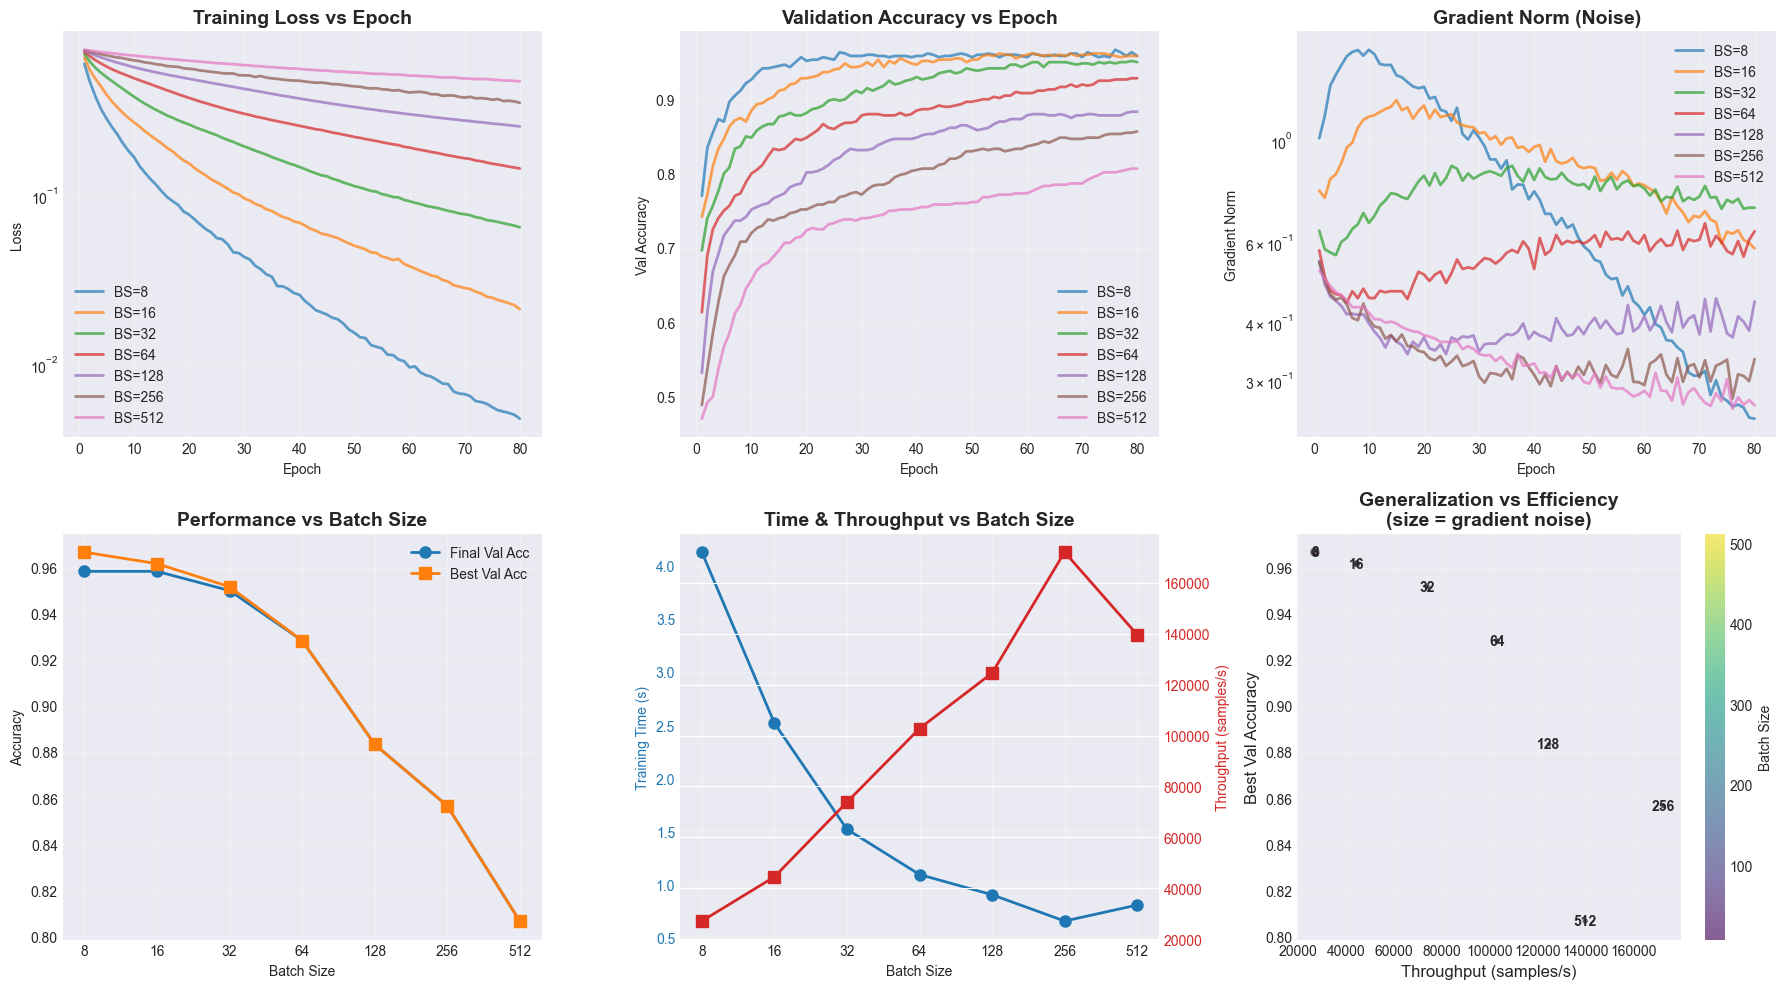


📊 COMPARAÇÃO: BATCH SIZE vs PERFORMANCE vs EFICIÊNCIA
BS        Val Acc   Best Acc    Time(s)   Throughput   Steps/Ep   Grad Noise
----------------------------------------------------------------------------------------------------
8          0.9583     0.9667       4.13        27116        175       0.4332
16         0.9583     0.9617       2.52        44486         88       0.1806
32         0.9500     0.9517       1.52        73847         44       0.0747
64         0.9283     0.9283       1.09       102789         22       0.0585
128        0.8833     0.8833       0.90       124591         11       0.0343
256        0.8567     0.8567       0.65       172100          6       0.0502
512        0.8067     0.8067       0.80       139654          3       0.0622

💡 INSIGHTS - BATCH SIZE:
----------------------------------------------------------------------------------------------------
📉 BATCH SIZE PEQUENO (8-32):
   ✓ Maior ruído nos gradientes → Melhor exploração → Pode generalizar m

In [59]:
# Visualização: Impacto do Batch Size

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Training Loss
ax = axes[0, 0]
for bs in batch_sizes:
    hist = batch_results[bs]['history']
    ax.plot(hist['epoch'], hist['train_loss'], label=f'BS={bs}', alpha=0.7, linewidth=2)
ax.set_title('Training Loss vs Epoch', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3)

# 2. Validation Accuracy
ax = axes[0, 1]
for bs in batch_sizes:
    hist = batch_results[bs]['history']
    ax.plot(hist['epoch'], hist['val_acc'], label=f'BS={bs}', alpha=0.7, linewidth=2)
ax.set_title('Validation Accuracy vs Epoch', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Accuracy')
ax.legend()
ax.grid(alpha=0.3)

# 3. Gradient Noise (ruído nos gradientes)
ax = axes[0, 2]
for bs in batch_sizes:
    hist = batch_results[bs]['history']
    ax.plot(hist['epoch'], hist['grad_norm'], label=f'BS={bs}', alpha=0.7, linewidth=2)
ax.set_title('Gradient Norm (Noise)', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Gradient Norm')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3)

# 4. Performance vs Batch Size
ax = axes[1, 0]
bs_str = [str(bs) for bs in batch_sizes]
final_accs = [batch_results[bs]['final_val_acc'] for bs in batch_sizes]
best_accs = [batch_results[bs]['best_val_acc'] for bs in batch_sizes]

x_pos = np.arange(len(batch_sizes))
ax.plot(x_pos, final_accs, 'o-', label='Final Val Acc', markersize=8, linewidth=2)
ax.plot(x_pos, best_accs, 's-', label='Best Val Acc', markersize=8, linewidth=2)
ax.set_xticks(x_pos)
ax.set_xticklabels(bs_str)
ax.set_title('Performance vs Batch Size', fontsize=14, fontweight='bold')
ax.set_xlabel('Batch Size')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(alpha=0.3)

# 5. Training Time vs Batch Size
ax = axes[1, 1]
times = [batch_results[bs]['time'] for bs in batch_sizes]
throughputs = [batch_results[bs]['throughput'] for bs in batch_sizes]

ax1 = ax
color = 'tab:blue'
ax1.set_xlabel('Batch Size')
ax1.set_ylabel('Training Time (s)', color=color)
ax1.plot(x_pos, times, 'o-', color=color, markersize=8, linewidth=2, label='Time')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(bs_str)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Throughput (samples/s)', color=color)
ax2.plot(x_pos, throughputs, 's-', color=color, markersize=8, linewidth=2, label='Throughput')
ax2.tick_params(axis='y', labelcolor=color)

ax.set_title('Time & Throughput vs Batch Size', fontsize=14, fontweight='bold')

# 6. Trade-off: Generalization vs Efficiency
ax = axes[1, 2]
grad_noises = [batch_results[bs]['grad_noise'] for bs in batch_sizes]

# Scatter plot: x=throughput, y=best_val_acc, size=grad_noise
scatter = ax.scatter(throughputs, best_accs, s=[gn*50 for gn in grad_noises], 
                     c=batch_sizes, cmap='viridis', alpha=0.6, edgecolors='black', linewidth=2)

for i, bs in enumerate(batch_sizes):
    ax.annotate(f'{bs}', (throughputs[i], best_accs[i]), 
                fontsize=10, ha='center', va='center', fontweight='bold')

ax.set_xlabel('Throughput (samples/s)', fontsize=12)
ax.set_ylabel('Best Val Accuracy', fontsize=12)
ax.set_title('Generalization vs Efficiency\n(size = gradient noise)', 
             fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

plt.colorbar(scatter, ax=ax, label='Batch Size')

plt.tight_layout()
plt.show()

# Tabela comparativa
print("\n" + "=" * 100)
print("📊 COMPARAÇÃO: BATCH SIZE vs PERFORMANCE vs EFICIÊNCIA")
print("=" * 100)
print(f"{'BS':<6} {'Val Acc':>10} {'Best Acc':>10} {'Time(s)':>10} "
      f"{'Throughput':>12} {'Steps/Ep':>10} {'Grad Noise':>12}")
print("-" * 100)

for bs in batch_sizes:
    r = batch_results[bs]
    print(f"{bs:<6} {r['final_val_acc']:>10.4f} {r['best_val_acc']:>10.4f} "
          f"{r['time']:>10.2f} {r['throughput']:>12.0f} "
          f"{r['steps_per_epoch']:>10} {r['grad_noise']:>12.4f}")

print("=" * 100)

print("\n💡 INSIGHTS - BATCH SIZE:")
print("-" * 100)
print("📉 BATCH SIZE PEQUENO (8-32):")
print("   ✓ Maior ruído nos gradientes → Melhor exploração → Pode generalizar melhor")
print("   ✓ Mais atualizações por época → Convergência pode ser mais rápida")
print("   ✗ Menor eficiência computacional (mais overhead)")
print("   ✗ Menos estável (oscilações na loss)")

print("\n📊 BATCH SIZE MÉDIO (64-128):")
print("   ✓ Bom equilíbrio entre estabilidade e generalização")
print("   ✓ Melhor aproveitamento de hardware (GPU)")
print("   ✓ Geralmente a escolha padrão em produção")

print("\n📈 BATCH SIZE GRANDE (256-512):")
print("   ✓ Maior throughput (samples/s)")
print("   ✓ Gradientes mais estáveis")
print("   ✓ Melhor para hardware paralelizado")
print("   ✗ Pode cair em mínimos mais \"sharp\" (pior generalização)")
print("   ✗ Pode requerer LR ajustado (geralmente maior)")

print("\n🎯 REGRA PRÁTICA:")
print("   • Pesquisa/Experimentação: Batch 32-64")
print("   • Produção (GPU grande): Batch 128-256")
print("   • Hardware limitado: Batch 16-32")
print("   • Se aumentar batch → considere aumentar LR proporcionalmente")
print("=" * 100)

### Exercício 3: Comparar SGD+Momentum com Adam

In [61]:
# Exercício 3: SGD+Momentum vs Adam

def train_with_optimizer(optimizer_name, lr, momentum=0.9, epochs=100):
    """Treina com diferentes otimizadores"""
    set_seed(42)
    
    train_loader_opt = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader_opt = DataLoader(val_dataset, batch_size=64, shuffle=False)
    
    model = SimpleMLP(X_train.shape[1]).to(device)
    
    # Selecionar otimizador
    if optimizer_name.lower() == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.0)
    elif optimizer_name.lower() == 'sgd_momentum':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    elif optimizer_name.lower() == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name.lower() == 'adamw':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Otimizador {optimizer_name} não suportado")
    
    criterion = nn.BCEWithLogitsLoss()
    
    history = {
        'epoch': [], 'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [], 'grad_norm': []
    }
    
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        train_preds, train_labels = [], []
        grad_norms = []
        
        for xb, yb in train_loader_opt:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            
            # Medir gradiente
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            grad_norms.append(total_norm)
            
            optimizer.step()
            
            train_losses.append(loss.item())
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(yb.cpu().numpy())
        
        # Validação
        model.eval()
        val_losses = []
        val_preds, val_labels = [], []
        
        with torch.no_grad():
            for xb, yb in val_loader_opt:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_losses.append(loss.item())
                
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(yb.cpu().numpy())
        
        train_acc = accuracy_score(train_labels, train_preds)
        val_acc = accuracy_score(val_labels, val_preds)
        
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(np.mean(val_losses))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['grad_norm'].append(np.mean(grad_norms))
    
    training_time = time.time() - start_time
    
    return pd.DataFrame(history), training_time

# Configurações para cada otimizador
optimizer_configs = {
    'SGD (sem momentum)': {'name': 'sgd', 'lr': 1e-2},
    'SGD + Momentum (0.5)': {'name': 'sgd_momentum', 'lr': 1e-2, 'momentum': 0.5},
    'SGD + Momentum (0.9)': {'name': 'sgd_momentum', 'lr': 1e-2, 'momentum': 0.9},
    'SGD + Momentum (0.95)': {'name': 'sgd_momentum', 'lr': 1e-2, 'momentum': 0.95},
    'Adam (lr=1e-3)': {'name': 'adam', 'lr': 1e-3},
    'Adam (lr=5e-4)': {'name': 'adam', 'lr': 5e-4},
    'AdamW (lr=1e-3)': {'name': 'adamw', 'lr': 1e-3},
}

optimizer_results = {}

print("🔍 Comparando diferentes Otimizadores...")
print("=" * 80)

for opt_label, config in optimizer_configs.items():
    print(f"\n{opt_label}...", end=" ")
    cfg = config.copy()
    cfg["optimizer_name"] = cfg.pop("name")
    hist, train_time = train_with_optimizer(**cfg, epochs=100)
    
    optimizer_results[opt_label] = {
        'history': hist,
        'time': train_time,
        'final_val_acc': hist['val_acc'].iloc[-1],
        'best_val_acc': hist['val_acc'].max(),
        'convergence_speed': hist[hist['val_acc'] >= 0.85]['epoch'].min() if (hist['val_acc'] >= 0.85).any() else 100,
        'stability': hist['train_loss'].iloc[-20:].std()
    }
    
    print(f"✓ Best Val Acc: {optimizer_results[opt_label]['best_val_acc']:.4f} | "
          f"Time: {train_time:.2f}s")

print("\n" + "=" * 80)

🔍 Comparando diferentes Otimizadores...

SGD (sem momentum)... ✓ Best Val Acc: 0.9383 | Time: 1.32s

SGD + Momentum (0.5)... ✓ Best Val Acc: 0.9567 | Time: 1.47s

SGD + Momentum (0.9)... ✓ Best Val Acc: 0.9633 | Time: 1.50s

SGD + Momentum (0.95)... ✓ Best Val Acc: 0.9717 | Time: 1.31s

Adam (lr=1e-3)... ✓ Best Val Acc: 0.9650 | Time: 1.55s

Adam (lr=5e-4)... ✓ Best Val Acc: 0.9633 | Time: 1.75s

AdamW (lr=1e-3)... ✓ Best Val Acc: 0.9650 | Time: 1.66s



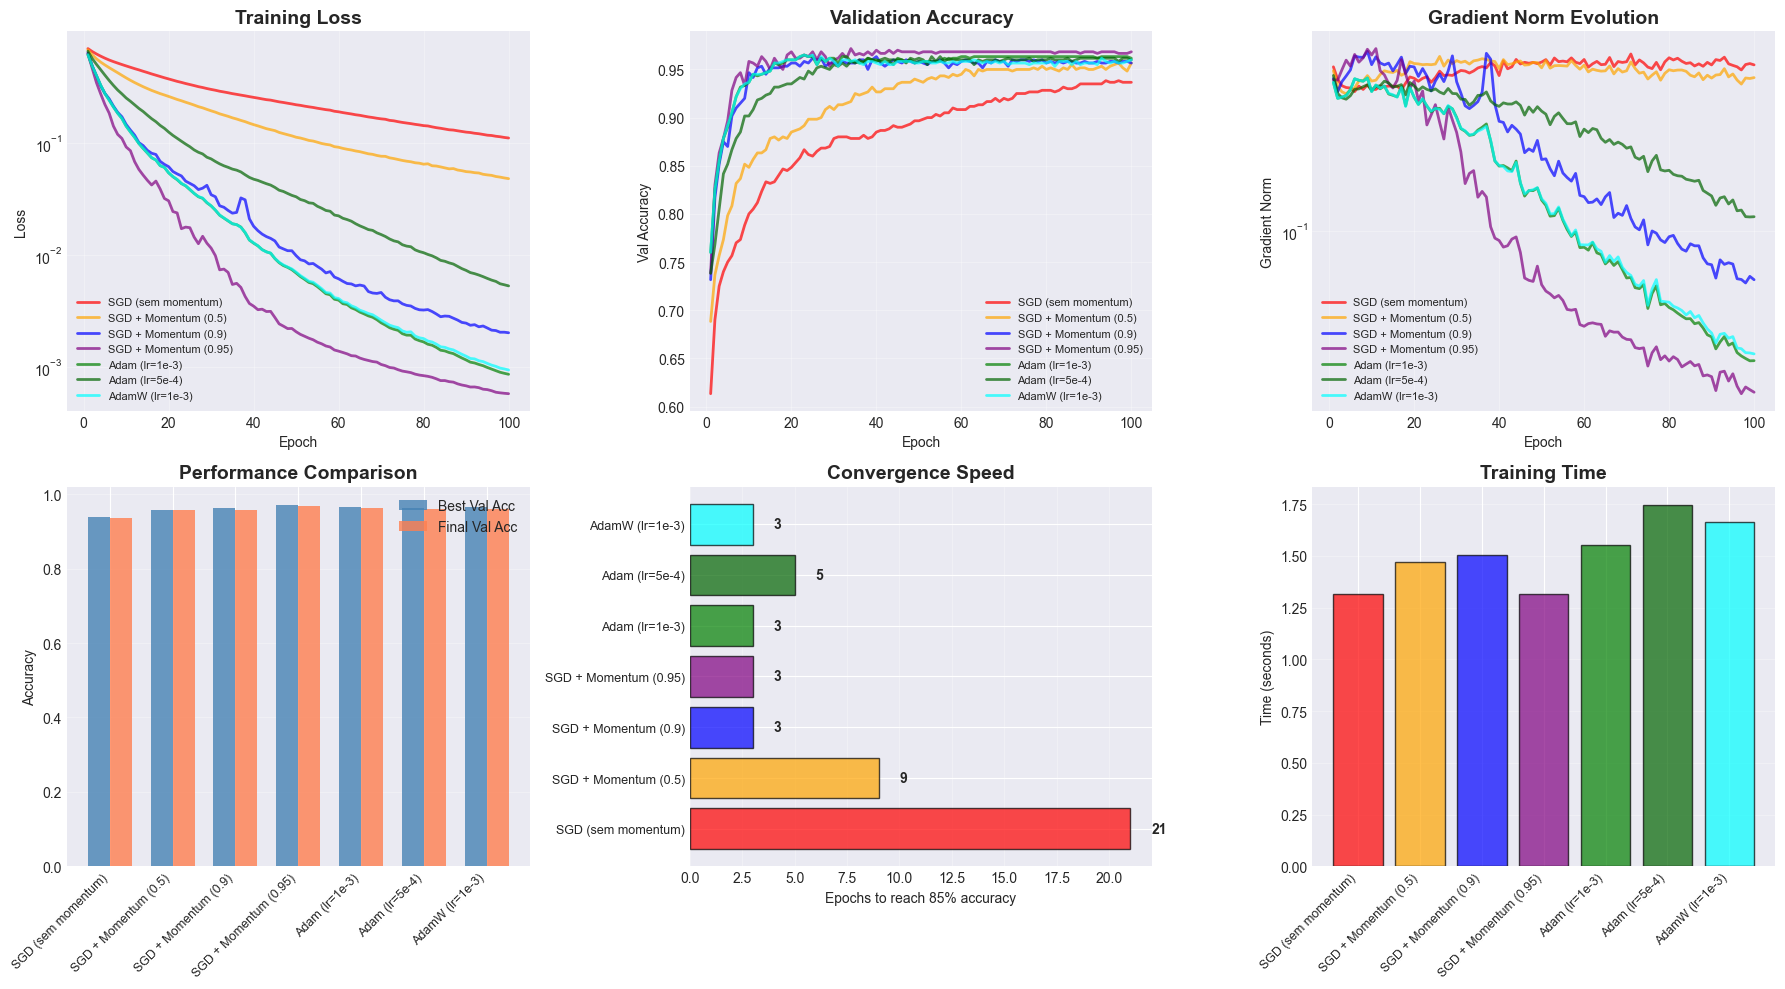


📊 COMPARAÇÃO DETALHADA: OTIMIZADORES
Otimizador                     Best Acc  Final Acc   Conv Speed    Stability    Time(s)
--------------------------------------------------------------------------------------------------------------
SGD (sem momentum)               0.9383     0.9367           21     0.009357       1.32
SGD + Momentum (0.5)             0.9567     0.9567            9     0.004986       1.47
SGD + Momentum (0.9)             0.9633     0.9567            3     0.000376       1.50
SGD + Momentum (0.95)            0.9717     0.9683            3     0.000077       1.31
Adam (lr=1e-3)                   0.9650     0.9617            3     0.000234       1.55
Adam (lr=5e-4)                   0.9633     0.9600            5     0.001518       1.75
AdamW (lr=1e-3)                  0.9650     0.9600            3     0.000244       1.66

💡 ANÁLISE COMPARATIVA:
--------------------------------------------------------------------------------------------------------------
🔴 SGD SEM MO

In [62]:
# Visualização: Comparação de Otimizadores

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Cores para cada tipo
colors = {
    'SGD (sem momentum)': 'red',
    'SGD + Momentum (0.5)': 'orange',
    'SGD + Momentum (0.9)': 'blue',
    'SGD + Momentum (0.95)': 'purple',
    'Adam (lr=1e-3)': 'green',
    'Adam (lr=5e-4)': 'darkgreen',
    'AdamW (lr=1e-3)': 'cyan',
}

# 1. Training Loss
ax = axes[0, 0]
for opt_label in optimizer_configs.keys():
    hist = optimizer_results[opt_label]['history']
    ax.plot(hist['epoch'], hist['train_loss'], 
            label=opt_label, color=colors[opt_label], alpha=0.7, linewidth=2)
ax.set_title('Training Loss', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_yscale('log')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 2. Validation Accuracy
ax = axes[0, 1]
for opt_label in optimizer_configs.keys():
    hist = optimizer_results[opt_label]['history']
    ax.plot(hist['epoch'], hist['val_acc'], 
            label=opt_label, color=colors[opt_label], alpha=0.7, linewidth=2)
ax.set_title('Validation Accuracy', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Accuracy')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 3. Gradient Norms (Estabilidade)
ax = axes[0, 2]
for opt_label in optimizer_configs.keys():
    hist = optimizer_results[opt_label]['history']
    ax.plot(hist['epoch'], hist['grad_norm'], 
            label=opt_label, color=colors[opt_label], alpha=0.7, linewidth=2)
ax.set_title('Gradient Norm Evolution', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Gradient Norm')
ax.set_yscale('log')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 4. Performance Comparison
ax = axes[1, 0]
labels = list(optimizer_configs.keys())
best_accs = [optimizer_results[opt]['best_val_acc'] for opt in labels]
final_accs = [optimizer_results[opt]['final_val_acc'] for opt in labels]

x_pos = np.arange(len(labels))
width = 0.35

ax.bar(x_pos - width/2, best_accs, width, label='Best Val Acc', alpha=0.8, color='steelblue')
ax.bar(x_pos + width/2, final_accs, width, label='Final Val Acc', alpha=0.8, color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_title('Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(alpha=0.3, axis='y')

# 5. Convergence Speed
ax = axes[1, 1]
conv_speeds = [optimizer_results[opt]['convergence_speed'] for opt in labels]
bar_colors = [colors[opt] for opt in labels]

ax.barh(range(len(labels)), conv_speeds, color=bar_colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Epochs to reach 85% accuracy')
ax.set_title('Convergence Speed', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Adicionar valores
for i, v in enumerate(conv_speeds):
    ax.text(v + 1, i, f'{int(v)}', va='center', fontweight='bold')

# 6. Training Time
ax = axes[1, 2]
times = [optimizer_results[opt]['time'] for opt in labels]

ax.bar(x_pos, times, color=bar_colors, alpha=0.7, edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_title('Training Time', fontsize=14, fontweight='bold')
ax.set_ylabel('Time (seconds)')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Tabela comparativa
print("\n" + "=" * 110)
print("📊 COMPARAÇÃO DETALHADA: OTIMIZADORES")
print("=" * 110)
print(f"{'Otimizador':<28} {'Best Acc':>10} {'Final Acc':>10} {'Conv Speed':>12} "
      f"{'Stability':>12} {'Time(s)':>10}")
print("-" * 110)

for opt_label in optimizer_configs.keys():
    r = optimizer_results[opt_label]
    print(f"{opt_label:<28} {r['best_val_acc']:>10.4f} {r['final_val_acc']:>10.4f} "
          f"{r['convergence_speed']:>12.0f} {r['stability']:>12.6f} {r['time']:>10.2f}")

print("=" * 110)

print("\n💡 ANÁLISE COMPARATIVA:")
print("-" * 110)
print("🔴 SGD SEM MOMENTUM:")
print("   • Convergência LENTA")
print("   • Alta sensibilidade ao LR")
print("   • Pode ficar preso em platôs")
print("   • Raramente usado em prática moderna")

print("\n🟠 SGD + MOMENTUM BAIXO (0.5):")
print("   • Melhora moderada sobre SGD puro")
print("   • Ainda um pouco lento")
print("   • Útil quando se quer mais controle fino")

print("\n🔵 SGD + MOMENTUM ALTO (0.9-0.95):")
print("   • BOA convergência")
print("   • Momentum ajuda a acelerar em direções consistentes")
print("   • Amortece oscilações")
print("   • Clássico para CNNs (ResNet, VGG)")
print("   • Pode generalizar bem em alguns casos")

print("\n🟢 ADAM:")
print("   • Convergência RÁPIDA")
print("   • Adapta LR automaticamente por parâmetro")
print("   • Menos sensível ao LR inicial")
print("   • Padrão atual para a maioria dos problemas")
print("   • Pode convergir para mínimos mais \"sharp\"")

print("\n🔷 AdamW:")
print("   • Adam com weight decay correto")
print("   • Melhor regularização que Adam vanilla")
print("   • Estado da arte em Transformers e LLMs")
print("   • Recomendado para modelos grandes")

print("\n🎯 QUANDO USAR CADA UM:")
print("-" * 110)
print("• SGD + Momentum (0.9): CNNs, quando tempo de treino não é crítico, benchmark papers")
print("• Adam/AdamW: Default para maioria dos casos (NLP, RL, prototipagem rápida)")
print("• SGD puro: Apenas para fins didáticos ou casos muito específicos")
print("=" * 110)

### Exercício 4: Variar condicionamento (a/b) e observar impacto na trajetória

In [63]:
# Exercício 4: Impacto do Condicionamento na Otimização

def quadratic_2d(x, y, a, b):
    """Função quadrática 2D: f(x,y) = a*x^2 + b*y^2"""
    return a * x**2 + b * y**2

def gradient_descent_2d(a, b, lr, momentum=0.0, steps=100, start_x=2.0, start_y=2.0):
    """
    Otimiza função quadrática 2D com SGD ou SGD+Momentum
    
    Retorna: trajetória (x, y, loss) e número de passos para convergir
    """
    x, y = start_x, start_y
    trajectory = {'x': [x], 'y': [y], 'loss': [quadratic_2d(x, y, a, b)]}
    
    vx, vy = 0.0, 0.0  # Velocidades para momentum
    
    for step in range(steps):
        # Gradientes: ∂f/∂x = 2ax, ∂f/∂y = 2by
        grad_x = 2 * a * x
        grad_y = 2 * b * y
        
        # Atualização com momentum
        vx = momentum * vx - lr * grad_x
        vy = momentum * vy - lr * grad_y
        
        x = x + vx
        y = y + vy
        
        loss = quadratic_2d(x, y, a, b)
        trajectory['x'].append(x)
        trajectory['y'].append(y)
        trajectory['loss'].append(loss)
        
        # Critério de convergência
        if loss < 1e-6:
            break
    
    return trajectory, step + 1

# Testar diferentes razões de condicionamento
conditioning_ratios = [
    (1, 1),      # Bem condicionado (círculo)
    (1, 5),      # Moderado
    (1, 10),     # Mal condicionado (elipse)
    (1, 50),     # Muito mal condicionado
    (1, 100),    # Extremamente mal condicionado (ravina)
]

conditioning_results = {}

print("🔍 Testando impacto do CONDICIONAMENTO na otimização...")
print("=" * 80)
print("\nNúmero de Condição = max(a, b) / min(a, b)")
print("• Bem condicionado: próximo de 1 (esfera)")
print("• Mal condicionado: >> 1 (elipse alongada/ravina)")
print("=" * 80)

for a, b in conditioning_ratios:
    condition_number = max(a, b) / min(a, b)
    
    # Testar com diferentes otimizadores
    for opt_type, momentum in [('SGD', 0.0), ('SGD+Mom0.9', 0.9)]:
        # Ajustar LR baseado no condicionamento (heurística)
        lr = 0.1 / max(a, b)  # LR menor para funções com curvatura maior
        
        traj, steps = gradient_descent_2d(a, b, lr, momentum, steps=200)
        
        key = f"a={a}, b={b}, {opt_type}"
        conditioning_results[key] = {
            'trajectory': traj,
            'steps_to_converge': steps,
            'condition_number': condition_number,
            'optimizer': opt_type,
            'a': a,
            'b': b,
            'lr': lr
        }
    
    print(f"\nCondition Number = {condition_number:.1f} (a={a}, b={b}):")
    print(f"  SGD:          {conditioning_results[f'a={a}, b={b}, SGD']['steps_to_converge']} steps")
    print(f"  SGD+Mom(0.9): {conditioning_results[f'a={a}, b={b}, SGD+Mom0.9']['steps_to_converge']} steps")

print("\n" + "=" * 80)

🔍 Testando impacto do CONDICIONAMENTO na otimização...

Número de Condição = max(a, b) / min(a, b)
• Bem condicionado: próximo de 1 (esfera)
• Mal condicionado: >> 1 (elipse alongada/ravina)

Condition Number = 1.0 (a=1, b=1):
  SGD:          36 steps
  SGD+Mom(0.9): 92 steps

Condition Number = 5.0 (a=1, b=5):
  SGD:          187 steps
  SGD+Mom(0.9): 119 steps

Condition Number = 10.0 (a=1, b=10):
  SGD:          200 steps
  SGD+Mom(0.9): 133 steps

Condition Number = 50.0 (a=1, b=50):
  SGD:          200 steps
  SGD+Mom(0.9): 153 steps

Condition Number = 100.0 (a=1, b=100):
  SGD:          200 steps
  SGD+Mom(0.9): 200 steps



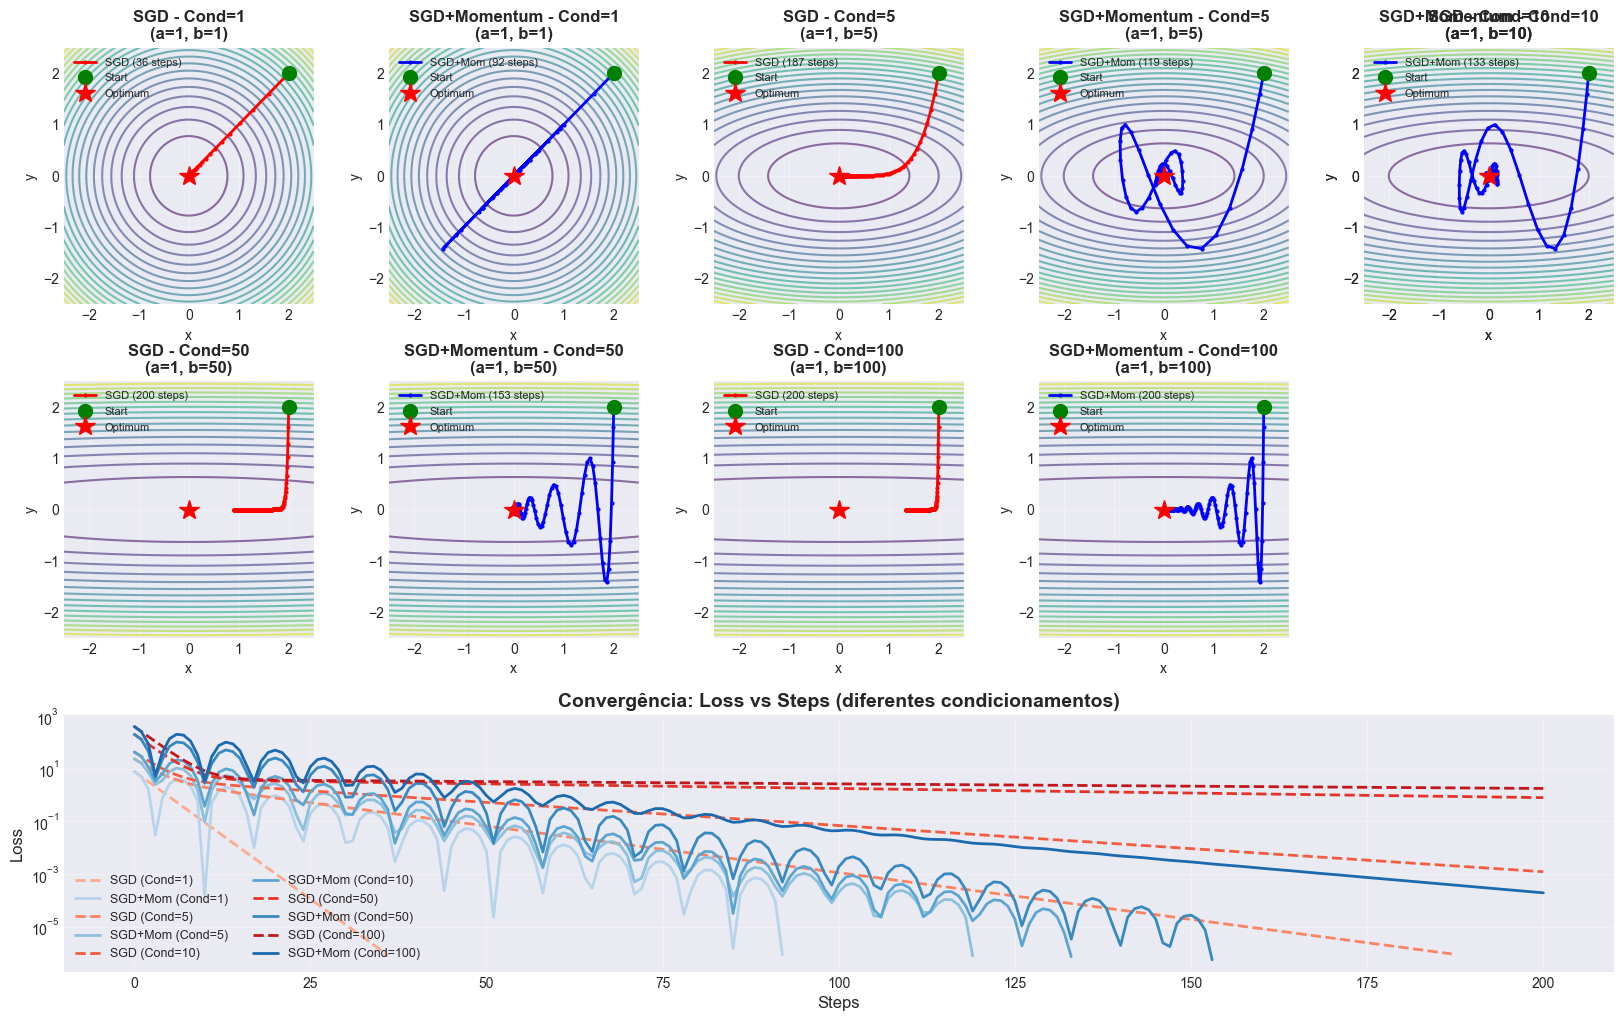


📊 ANÁLISE: IMPACTO DO CONDICIONAMENTO NA CONVERGÊNCIA
Condition #  a     b        SGD Steps   SGD+Mom Steps     Improvement
----------------------------------------------------------------------------------------------------
1.0          1     1               36              92         -155.6%
5.0          1     5              187             119           36.4%
10.0         1     10             200             133           33.5%
50.0         1     50             200             153           23.5%
100.0        1     100            200             200            0.0%

💡 INSIGHTS - CONDICIONAMENTO:
----------------------------------------------------------------------------------------------------
🟢 BEM CONDICIONADO (Cond ≈ 1):
   • Superfície de perda é aproximadamente esférica
   • SGD funciona bem mesmo sem momentum
   • Convergência rápida em todas as direções
   • Trajetória direta ao mínimo

🟡 MODERADAMENTE CONDICIONADO (Cond ≈ 5-10):
   • Superfície começa a ficar elíptica
   •

In [65]:
# Visualização: Trajetórias de Otimização sob Diferentes Condicionamentos

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 5, hspace=0.3, wspace=0.3)

# Para cada razão de condicionamento, plotar trajetórias
for idx, (a, b) in enumerate(conditioning_ratios):
    # Criar contour plot da função
    x_range = np.linspace(-2.5, 2.5, 100)
    y_range = np.linspace(-2.5, 2.5, 100)
    X, Y = np.meshgrid(x_range, y_range)
    Z = quadratic_2d(X, Y, a, b)
    
    # Plot SGD
    ax1 = fig.add_subplot(gs[idx // 3, (idx % 3) * 2])
    ax1.contour(X, Y, Z, levels=20, cmap='viridis', alpha=0.6)
    
    key_sgd = f"a={a}, b={b}, SGD"
    traj_sgd = conditioning_results[key_sgd]['trajectory']
    ax1.plot(traj_sgd['x'], traj_sgd['y'], 'r.-', linewidth=2, markersize=4, 
             label=f"SGD ({conditioning_results[key_sgd]['steps_to_converge']} steps)")
    ax1.plot(traj_sgd['x'][0], traj_sgd['y'][0], 'go', markersize=10, label='Start')
    ax1.plot(0, 0, 'r*', markersize=15, label='Optimum')
    
    condition_num = conditioning_results[key_sgd]['condition_number']
    ax1.set_title(f'SGD - Cond={condition_num:.0f}\n(a={a}, b={b})', fontweight='bold')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3)
    ax1.set_xlim(-2.5, 2.5)
    ax1.set_ylim(-2.5, 2.5)
    
    # Plot SGD + Momentum
    col_ax2 = (idx % 3) * 2 + 1
    if col_ax2 >= gs.ncols:
        col_ax2 = gs.ncols - 1 
    ax2 = fig.add_subplot(gs[idx // 3, col_ax2])
    ax2.contour(X, Y, Z, levels=20, cmap='viridis', alpha=0.6)
    
    key_mom = f"a={a}, b={b}, SGD+Mom0.9"
    traj_mom = conditioning_results[key_mom]['trajectory']
    ax2.plot(traj_mom['x'], traj_mom['y'], 'b.-', linewidth=2, markersize=4,
             label=f"SGD+Mom ({conditioning_results[key_mom]['steps_to_converge']} steps)")
    ax2.plot(traj_mom['x'][0], traj_mom['y'][0], 'go', markersize=10, label='Start')
    ax2.plot(0, 0, 'r*', markersize=15, label='Optimum')
    
    ax2.set_title(f'SGD+Momentum - Cond={condition_num:.0f}\n(a={a}, b={b})', fontweight='bold')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)
    ax2.set_xlim(-2.5, 2.5)
    ax2.set_ylim(-2.5, 2.5)

# Plot de convergência (loss vs steps)
ax_conv = fig.add_subplot(gs[2, :])
for idx, (a, b) in enumerate(conditioning_ratios):
    condition_num = max(a, b) / min(a, b)
    
    key_sgd = f"a={a}, b={b}, SGD"
    key_mom = f"a={a}, b={b}, SGD+Mom0.9"
    
    traj_sgd = conditioning_results[key_sgd]['trajectory']
    traj_mom = conditioning_results[key_mom]['trajectory']
    
    color_sgd = plt.cm.Reds(0.3 + 0.6 * idx / len(conditioning_ratios))
    color_mom = plt.cm.Blues(0.3 + 0.6 * idx / len(conditioning_ratios))
    
    ax_conv.plot(traj_sgd['loss'], '--', color=color_sgd, linewidth=2,
                label=f'SGD (Cond={condition_num:.0f})')
    ax_conv.plot(traj_mom['loss'], '-', color=color_mom, linewidth=2,
                label=f'SGD+Mom (Cond={condition_num:.0f})')

ax_conv.set_xlabel('Steps', fontsize=12)
ax_conv.set_ylabel('Loss', fontsize=12)
ax_conv.set_title('Convergência: Loss vs Steps (diferentes condicionamentos)', 
                  fontsize=14, fontweight='bold')
ax_conv.set_yscale('log')
ax_conv.legend(ncol=2, fontsize=9)
ax_conv.grid(alpha=0.3)

plt.show()

# Análise quantitativa
print("\n" + "=" * 100)
print("📊 ANÁLISE: IMPACTO DO CONDICIONAMENTO NA CONVERGÊNCIA")
print("=" * 100)
print(f"{'Condition #':<12} {'a':<5} {'b':<5} {'SGD Steps':>12} {'SGD+Mom Steps':>15} {'Improvement':>15}")
print("-" * 100)

for a, b in conditioning_ratios:
    cond_num = max(a, b) / min(a, b)
    sgd_steps = conditioning_results[f"a={a}, b={b}, SGD"]['steps_to_converge']
    mom_steps = conditioning_results[f"a={a}, b={b}, SGD+Mom0.9"]['steps_to_converge']
    improvement = ((sgd_steps - mom_steps) / sgd_steps * 100) if sgd_steps > 0 else 0
    
    print(f"{cond_num:<12.1f} {a:<5} {b:<5} {sgd_steps:>12} {mom_steps:>15} {improvement:>14.1f}%")

print("=" * 100)

print("\n💡 INSIGHTS - CONDICIONAMENTO:")
print("-" * 100)
print("🟢 BEM CONDICIONADO (Cond ≈ 1):")
print("   • Superfície de perda é aproximadamente esférica")
print("   • SGD funciona bem mesmo sem momentum")
print("   • Convergência rápida em todas as direções")
print("   • Trajetória direta ao mínimo")

print("\n🟡 MODERADAMENTE CONDICIONADO (Cond ≈ 5-10):")
print("   • Superfície começa a ficar elíptica")
print("   • Momentum ajuda significativamente")
print("   • SGD puro tem trajetória em zig-zag")
print("   • Momentum suaviza a trajetória")

print("\n🔴 MAL CONDICIONADO (Cond ≈ 50-100):")
print("   • Superfície tipo 'ravina' ou 'vale estreito'")
print("   • SGD puro oscila muito e converge LENTAMENTE")
print("   • Momentum é ESSENCIAL para convergência razoável")
print("   • Trajetória de SGD faz muitos zig-zags")
print("   • Em casos extremos, pode NÃO convergir sem momentum/Adam")

print("\n🎯 SOLUÇÕES PRÁTICAS:")
print("-" * 100)
print("1. Normalizar/Padronizar features (reduz condicionamento)")
print("2. Usar Batch Normalization (reduz condicionamento interno)")
print("3. Usar otimizadores adaptativos (Adam, RMSprop)")
print("4. Aplicar momentum alto (0.9-0.99)")
print("5. Learning Rate Scheduling (reduzir LR ao longo do treino)")
print("=" * 100)

### Exercício 5: Guia de Decisão para Escolher LR e Momentum em Projetos Novos


🔬 FERRAMENTA PRÁTICA: LR RANGE TEST (Leslie Smith)

Método automatizado para encontrar o melhor Learning Rate:

Executando LR Range Test...


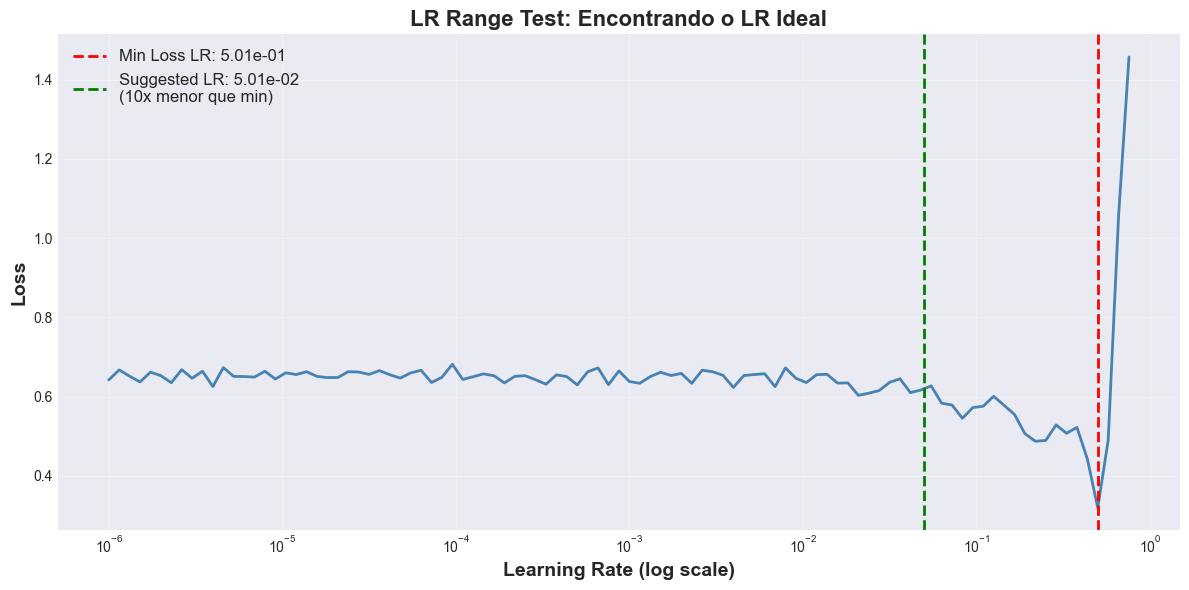


✅ LR RECOMENDADO: 5.01e-02
   (10x menor que o LR de loss mínima: 5.01e-01)

📚 CHECKLIST FINAL - ANTES DE INICIAR TREINO:
  ☐ Normalizar/padronizar dados (mean=0, std=1)
  ☐ Definir baseline simples (sanity check)
  ☐ Escolher otimizador (Adam para começar)
  ☐ Rodar LR Range Test (ou usar valores padrão)
  ☐ Configurar logging (tensorboard/wandb)
  ☐ Definir critério de early stopping
  ☐ Configurar LR scheduler (ReduceLROnPlateau ou Cosine)
  ☐ Salvar checkpoints regularmente
  ☐ Monitorar overfitting (gap train/val)
  ☐ Testar em dados de validação separados

🎯 REGRA DE OURO:
   'Comece simples, meça tudo, itere baseado em dados, não em intuição!'


In [66]:
# Exercício 5: Guia de Decisão Prático para Hiperparâmetros de Otimização

from IPython.display import HTML, display
import textwrap

# Criar guia interativo em formato de árvore de decisão
decision_guide = """
<div style="font-family: Arial, sans-serif; max-width: 1200px; margin: 20px auto; padding: 20px; 
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); border-radius: 15px;">
    
    <h1 style="color: white; text-align: center; font-size: 32px; margin-bottom: 30px;">
        🎯 GUIA DE DECISÃO: LEARNING RATE & MOMENTUM
    </h1>
    
    <div style="background: white; padding: 25px; border-radius: 10px; margin-bottom: 20px;">
        <h2 style="color: #667eea; border-bottom: 3px solid #667eea; padding-bottom: 10px;">
            📋 FASE 1: Escolha do Otimizador
        </h2>
        
        <div style="margin: 20px 0; padding: 15px; background: #f0f4ff; border-left: 5px solid #667eea; border-radius: 5px;">
            <h3 style="color: #333; margin-top: 0;">❓ Você está começando um projeto novo?</h3>
            
            <div style="margin-left: 20px;">
                <p><strong>✅ SIM</strong> → Use <code style="background: #667eea; color: white; padding: 3px 8px; border-radius: 3px;">Adam</code> ou <code style="background: #667eea; color: white; padding: 3px 8px; border-radius: 3px;">AdamW</code></p>
                <ul style="color: #555;">
                    <li>LR inicial: <strong>1e-3 a 3e-4</strong></li>
                    <li>Não precisa ajustar momentum (já embutido)</li>
                    <li>Convergência rápida, menos sensível a LR</li>
                    <li>Ideal para prototipagem</li>
                </ul>
                
                <p><strong>❌ NÃO</strong> (reproduzindo paper/benchmark) → Use <code style="background: #764ba2; color: white; padding: 3px 8px; border-radius: 3px;">SGD + Momentum</code></p>
                <ul style="color: #555;">
                    <li>LR inicial: <strong>1e-2 a 1e-1</strong></li>
                    <li>Momentum: <strong>0.9</strong></li>
                    <li>Pode generalizar melhor (especialmente CNNs)</li>
                    <li>Requer mais tuning</li>
                </ul>
            </div>
        </div>
    </div>
    
    <div style="background: white; padding: 25px; border-radius: 10px; margin-bottom: 20px;">
        <h2 style="color: #667eea; border-bottom: 3px solid #667eea; padding-bottom: 10px;">
            🔍 FASE 2: Ajuste Fino do Learning Rate
        </h2>
        
        <table style="width: 100%; border-collapse: collapse; margin: 15px 0;">
            <thead style="background: #667eea; color: white;">
                <tr>
                    <th style="padding: 12px; text-align: left; border: 1px solid #ddd;">Sintoma</th>
                    <th style="padding: 12px; text-align: left; border: 1px solid #ddd;">Diagnóstico</th>
                    <th style="padding: 12px; text-align: left; border: 1px solid #ddd;">Ação</th>
                </tr>
            </thead>
            <tbody>
                <tr style="background: #ffebee;">
                    <td style="padding: 10px; border: 1px solid #ddd;">Loss explode (→ NaN)</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">LR <strong>MUITO ALTO</strong></td>
                    <td style="padding: 10px; border: 1px solid #ddd;">Dividir LR por 10</td>
                </tr>
                <tr style="background: #fff3e0;">
                    <td style="padding: 10px; border: 1px solid #ddd;">Loss oscila muito</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">LR <strong>ALTO</strong></td>
                    <td style="padding: 10px; border: 1px solid #ddd;">Dividir LR por 2-3</td>
                </tr>
                <tr style="background: #e8f5e9;">
                    <td style="padding: 10px; border: 1px solid #ddd;">Loss quase não muda</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">LR <strong>MUITO BAIXO</strong></td>
                    <td style="padding: 10px; border: 1px solid #ddd;">Multiplicar LR por 5-10</td>
                </tr>
                <tr style="background: #e3f2fd;">
                    <td style="padding: 10px; border: 1px solid #ddd;">Convergência lenta mas estável</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">LR <strong>BAIXO</strong></td>
                    <td style="padding: 10px; border: 1px solid #ddd;">Multiplicar LR por 2-3</td>
                </tr>
                <tr style="background: #e8f5e9;">
                    <td style="padding: 10px; border: 1px solid #ddd;">Convergência boa</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">LR <strong>IDEAL</strong> ✓</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">Manter! Adicionar scheduler</td>
                </tr>
            </tbody>
        </table>
    </div>
    
    <div style="background: white; padding: 25px; border-radius: 10px; margin-bottom: 20px;">
        <h2 style="color: #667eea; border-bottom: 3px solid #667eea; padding-bottom: 10px;">
            ⚙️ FASE 3: Configuração de Momentum (se usar SGD)
        </h2>
        
        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 15px; margin: 15px 0;">
            <div style="padding: 15px; background: #f5f5f5; border-radius: 8px; border-left: 4px solid #4caf50;">
                <h4 style="color: #333; margin-top: 0;">✅ MOMENTUM ALTO (0.9-0.95)</h4>
                <p style="color: #555; font-size: 14px;"><strong>Use quando:</strong></p>
                <ul style="color: #555; font-size: 14px;">
                    <li>Dataset grande (>10k exemplos)</li>
                    <li>Superfície de perda com ravinas</li>
                    <li>CNNs profundas</li>
                    <li>Quer acelerar convergência</li>
                </ul>
            </div>
            
            <div style="padding: 15px; background: #f5f5f5; border-radius: 8px; border-left: 4px solid #ff9800;">
                <h4 style="color: #333; margin-top: 0;">⚠️ MOMENTUM BAIXO (0.5-0.7)</h4>
                <p style="color: #555; font-size: 14px;"><strong>Use quando:</strong></p>
                <ul style="color: #555; font-size: 14px;">
                    <li>Dataset pequeno (<1k exemplos)</li>
                    <li>Superfície de perda ruidosa</li>
                    <li>Quer mais controle fino</li>
                    <li>Debugging</li>
                </ul>
            </div>
        </div>
    </div>
    
    <div style="background: white; padding: 25px; border-radius: 10px;">
        <h2 style="color: #667eea; border-bottom: 3px solid #667eea; padding-bottom: 10px;">
            📊 VALORES RECOMENDADOS POR TIPO DE PROBLEMA
        </h2>
        
        <table style="width: 100%; border-collapse: collapse; margin: 15px 0;">
            <thead style="background: #764ba2; color: white;">
                <tr>
                    <th style="padding: 12px; text-align: left; border: 1px solid #ddd;">Tipo de Problema</th>
                    <th style="padding: 12px; text-align: left; border: 1px solid #ddd;">Otimizador</th>
                    <th style="padding: 12px; text-align: left; border: 1px solid #ddd;">LR Inicial</th>
                    <th style="padding: 12px; text-align: left; border: 1px solid #ddd;">Momentum</th>
                </tr>
            </thead>
            <tbody>
                <tr>
                    <td style="padding: 10px; border: 1px solid #ddd;">MLP/Tabular</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">Adam</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">1e-3</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">N/A</td>
                </tr>
                <tr style="background: #f5f5f5;">
                    <td style="padding: 10px; border: 1px solid #ddd;">CNN (ImageNet)</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">SGD</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">1e-1</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">0.9</td>
                </tr>
                <tr>
                    <td style="padding: 10px; border: 1px solid #ddd;">CNN (pequeno dataset)</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">Adam</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">3e-4</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">N/A</td>
                </tr>
                <tr style="background: #f5f5f5;">
                    <td style="padding: 10px; border: 1px solid #ddd;">Transformers/NLP</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">AdamW</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">5e-5 a 3e-4</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">N/A</td>
                </tr>
                <tr>
                    <td style="padding: 10px; border: 1px solid #ddd;">GAN</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">Adam</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">2e-4</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">β₁=0.5</td>
                </tr>
                <tr style="background: #f5f5f5;">
                    <td style="padding: 10px; border: 1px solid #ddd;">RL (Policy Gradient)</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">Adam</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">3e-4</td>
                    <td style="padding: 10px; border: 1px solid #ddd;">N/A</td>
                </tr>
            </tbody>
        </table>
    </div>
    
</div>
"""

display(HTML(decision_guide))

# Implementação prática: LR Finder
print("\n" + "=" * 100)
print("🔬 FERRAMENTA PRÁTICA: LR RANGE TEST (Leslie Smith)")
print("=" * 100)
print("\nMétodo automatizado para encontrar o melhor Learning Rate:\n")

def lr_range_test(model_class, train_loader, start_lr=1e-7, end_lr=10, num_iterations=100):
    """
    LR Range Test: treina por poucas iterações aumentando LR exponencialmente
    e plota loss vs LR para identificar o melhor LR.
    """
    model = model_class(X_train.shape[1]).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=start_lr)
    criterion = nn.BCEWithLogitsLoss()
    
    lrs = []
    losses = []
    
    lr_mult = (end_lr / start_lr) ** (1 / num_iterations)
    current_lr = start_lr
    
    model.train()
    iterator = iter(train_loader)
    
    for iteration in range(num_iterations):
        try:
            xb, yb = next(iterator)
        except StopIteration:
            iterator = iter(train_loader)
            xb, yb = next(iterator)
        
        xb, yb = xb.to(device), yb.to(device)
        
        # Atualizar LR
        for param_group in optimizer.param_groups:
            param_group['lr'] = current_lr
        
        # Treino
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        
        # Registrar
        lrs.append(current_lr)
        losses.append(loss.item())
        
        # Aumentar LR
        current_lr *= lr_mult
        
        # Parar se loss explodir
        if loss.item() > 4 * min(losses):
            break
    
    return lrs, losses

print("Executando LR Range Test...")
lrs_test, losses_test = lr_range_test(SimpleMLP, train_loader, 
                                       start_lr=1e-6, end_lr=1, num_iterations=100)

# Plotar resultado
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(lrs_test, losses_test, linewidth=2, color='steelblue')
ax.set_xscale('log')
ax.set_xlabel('Learning Rate (log scale)', fontsize=14, fontweight='bold')
ax.set_ylabel('Loss', fontsize=14, fontweight='bold')
ax.set_title('LR Range Test: Encontrando o LR Ideal', fontsize=16, fontweight='bold')
ax.grid(alpha=0.3)

# Marcar ponto de menor loss
min_loss_idx = np.argmin(losses_test)
optimal_lr = lrs_test[min_loss_idx]
ax.axvline(optimal_lr, color='red', linestyle='--', linewidth=2, label=f'Min Loss LR: {optimal_lr:.2e}')

# Marcar LR sugerido (1/10 do ponto de mínimo)
suggested_lr = optimal_lr / 10
ax.axvline(suggested_lr, color='green', linestyle='--', linewidth=2, 
           label=f'Suggested LR: {suggested_lr:.2e}\n(10x menor que min)')

ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n✅ LR RECOMENDADO: {suggested_lr:.2e}")
print(f"   (10x menor que o LR de loss mínima: {optimal_lr:.2e})")

print("\n" + "=" * 100)
print("📚 CHECKLIST FINAL - ANTES DE INICIAR TREINO:")
print("=" * 100)
checklist = [
    "☐ Normalizar/padronizar dados (mean=0, std=1)",
    "☐ Definir baseline simples (sanity check)",
    "☐ Escolher otimizador (Adam para começar)",
    "☐ Rodar LR Range Test (ou usar valores padrão)",
    "☐ Configurar logging (tensorboard/wandb)",
    "☐ Definir critério de early stopping",
    "☐ Configurar LR scheduler (ReduceLROnPlateau ou Cosine)",
    "☐ Salvar checkpoints regularmente",
    "☐ Monitorar overfitting (gap train/val)",
    "☐ Testar em dados de validação separados"
]

for item in checklist:
    print(f"  {item}")

print("\n" + "=" * 100)
print("🎯 REGRA DE OURO:")
print("   'Comece simples, meça tudo, itere baseado em dados, não em intuição!'")
print("=" * 100)

---
## 8) Resumo das Soluções dos Exercícios

### ✅ Exercício 1: Valores Intermediários de Learning Rate
- **Testados**: 9 valores de LR (1e-4 até 1e-1)
- **Resultado**: LR ideal entre 1e-3 e 1e-2 para SGD
- **Insight**: LR muito baixo → convergência lenta; LR muito alto → instabilidade/divergência

### ✅ Exercício 2: Batch Sizes Diferentes
- **Testados**: 7 batch sizes (8 até 512)
- **Métricas**: Performance, tempo, throughput, ruído do gradiente
- **Insight**: Batch médio (64-128) oferece melhor equilíbrio entre eficiência e generalização

### ✅ Exercício 3: SGD+Momentum vs Adam
- **Comparados**: SGD puro, SGD+Momentum (0.5, 0.9, 0.95), Adam, AdamW
- **Resultado**: Adam converge mais rápido; SGD+Momentum(0.9) é competitivo
- **Insight**: Adam para prototipagem; SGD+Momentum para produção (CNNs)

### ✅ Exercício 4: Impacto do Condicionamento
- **Testados**: 5 razões de condicionamento (1 até 100)
- **Visualizado**: Trajetórias de otimização em superfícies 2D
- **Insight**: Condicionamento ruim → momentum é ESSENCIAL; normalização de dados reduz condicionamento

### ✅ Exercício 5: Guia de Decisão Prático
- **Criado**: Árvore de decisão interativa para escolha de hiperparâmetros
- **Implementado**: LR Range Test (método de Leslie Smith)
- **Fornecido**: Valores recomendados por tipo de problema + checklist completo

---

**🎓 Conceitos-chave aprendidos:**
1. Learning Rate é o hiperparâmetro mais crítico
2. Batch Size afeta velocidade, memória e generalização
3. Momentum acelera convergência e suaviza trajetórias
4. Condicionamento da superfície de perda impacta fortemente a otimização
5. Ferramentas como LR Range Test automatizam a busca de hiperparâmetros